# 05 · MCA de la producción histórica de GAITANA

## Perfil productivo, grado comercial y recurrencia semanal

Este cuaderno analiza **toda la producción disponible de GAITANA**, leyendo los Excel de `Datos/Producción real`. El nombre del notebook se conserva; el periodo por defecto incluye todos los años encontrados. El año y la semana se calculan con calendario ISO desde la fecha de corte.

Preguntas:
1. ¿Qué categorías de producto y color suelen aparecer asociadas?
2. ¿Cómo se relaciona el grado comercial con ese perfil, sin confundir clasificación con calidad?
3. ¿Las mismas semanas muestran composiciones productivas parecidas entre años?
4. ¿Cambian las conclusiones al modificar las variables activas o la ponderación?

La limpieza sigue la lógica del notebook **03, sección “Importación de producción real y su respectiva limpieza”**. Se elimina `Sector`: identifica al supervisor y no forma parte de este estudio. Las conclusiones se generan con las salidas de esta ejecución. Es un análisis descriptivo de asociaciones, no un modelo causal ni un pronóstico.

## 0. Configuración y procedencia

Se reconocen las hojas por sus columnas de producción, no por un nombre fijo como `BD`. Esto incluye las continuaciones de fin de año. Se excluyen hojas auxiliares de supervisores y tablas sin ese esquema. Se filtra **GAITANA antes de imputar**, para que otra finca no aporte referencias al corte.

`ANIOS_ARCHIVO = None` carga todos los libros; por ejemplo `[2026]` limita la selección a ese archivo. `ANIOS_ISO` permite filtrar los registros por año ISO después de consolidar. La caché se guarda dentro de `Datos/modelado/mca_produccion` y se invalida cuando cambian las fuentes o las reglas.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, FileLink

RAIZ = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / "Notebooks").is_dir() and (p / "Datos").is_dir())
if str(RAIZ / "scripts") not in sys.path:
    sys.path.insert(0, str(RAIZ / "scripts"))
import mca_produccion as mp
import mca_auditoria as ma

CARPETA_PRODUCCION = RAIZ / "Datos" / "Producción real"
CARPETA_CACHE = RAIZ / "Datos" / "modelado" / "mca_produccion"
SALIDA = RAIZ / "Notebooks" / "informes" / "mca_gaitana"
SALIDA.mkdir(parents=True, exist_ok=True)
ANIOS_ARCHIVO = None
ANIOS_ISO = None
UMBRAL_RARO = 0.001  # Menos del 0,1 % de tallos: OTROS solo en variables del MCA.
SEMILLA = 42

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", palette="colorblind")
TABLAS = {}
COMENTARIOS = []

def comentar(texto):
    COMENTARIOS.append(texto)
    display(Markdown(texto))

def mostrar(nombre, tabla, n=20):
    TABLAS[nombre] = tabla.copy()
    display(tabla.head(n))

def guardar_figura(nombre):
    plt.tight_layout()
    plt.savefig(SALIDA / (nombre + ".png"), dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

print("Carpeta fuente:", CARPETA_PRODUCCION)
print("Finca del análisis: GAITANA")
display(pd.DataFrame([{"archivo": p.name, "MiB": p.stat().st_size / 1024**2}
                     for p in sorted(CARPETA_PRODUCCION.glob("*.xlsx")) if not p.name.startswith("~$")]))

Carpeta fuente: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Datos\Producción real
Finca del análisis: GAITANA


,archivo,MiB
0,Producción Acumulada 2021.xlsx,64.764
1,Producción Acumulada 2022.xlsx,71.091
2,Producción Acumulada 2023.xlsx,89.161
3,Producción Acumulada 2024.xlsx,107.234
4,Producción Acumulada 2025.xlsx,108.183
5,Producción Acumulada 2026.xlsx,79.657


In [2]:
# La primera ejecución lee Excel; las siguientes reutilizan las cachés verificadas.
prod, auditoria_fuentes, control_limpieza, solapamientos = mp.obtener_base(
    CARPETA_PRODUCCION, CARPETA_CACHE, ANIOS_ARCHIVO
)
if ANIOS_ISO is not None:
    prod = prod.loc[prod["anio"].isin(ANIOS_ISO)].copy()
assert prod["finca"].eq("GAITANA").all()

mostrar("fuentes", auditoria_fuentes.drop(columns="fincas", errors="ignore"), n=40)
mostrar("limpieza", control_limpieza, n=30)
print("Filas limpias seleccionadas:", f"{len(prod):,}")
print("Rango de fechas:", prod.fecha_corte.min(), "→", prod.fecha_corte.max())

Base limpia en caché: fuentes y reglas verificadas.


,archivo,hoja,estado,filas_leidas,filas_vacias,otras_fincas,sin_finca,filas_gaitana,columnas_ausentes,columnas_eliminadas,columnas
0,Producción Acumulada 2021.xlsx,Sheet1,produccion,"926,798.000",0.000,"235,867.000",0.000,"690,931.000","anio, tipo_inventario","ano, sector",NaN
1,Producción Acumulada 2021.xlsx,Hoja1,omitida_sin_esquema_produccion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"invernadero, todas"
2,Producción Acumulada 2021.xlsx,Supervisor,omitida_sin_esquema_produccion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"finca, gaitana"
3,Producción Acumulada 2022.xlsx,Supervisor,omitida_sin_esquema_produccion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
4,Producción Acumulada 2022.xlsx,Sheet1,produccion,"965,024.000",0.000,"252,813.000",0.000,"712,211.000","anio, tipo_corte, tipo_inventario","ano, inventario_fisico, sector",NaN
5,Producción Acumulada 2023.xlsx,Supervisor,omitida_sin_esquema_produccion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
6,Producción Acumulada 2023.xlsx,no borrar,omitida_sin_esquema_produccion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
7,Producción Acumulada 2023.xlsx,Sheet1,produccion,"1,042,035.000",0.000,"278,094.000",0.000,"763,941.000","anio, tipo_corte, tipo_inventario","ano, inventario_fisico, sector",NaN
8,Producción Acumulada 2023.xlsx,Hoja1,produccion,"95,268.000",0.000,"25,615.000",0.000,"69,653.000",anio,"ano, inventario_fisico, reintegro, ajuste, fec...",NaN
9,Producción Acumulada 2024.xlsx,Supervisor,omitida_sin_esquema_produccion,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


,control,valor
0,Filas GAITANA cargadas,"4,690,522.000"
1,Copias exactas entre fuentes retiradas,"52,305.000"
2,Filas conservadas,"4,638,217.000"
3,Tallos conservados,"326,664,331.000"
4,Cortes faltantes antes,"1,913,968.000"
5,Cortes imputados,"37,110.000"
6,Cortes sin referencia,"1,876,858.000"
7,Fechas inválidas,0.000
8,Pesos no positivos o desconocidos,0.000


Filas limpias seleccionadas: 4,638,217
Rango de fechas: 2021-01-04 00:00:00 → 2026-08-29 00:00:00


### 0.1. Qué se elimina, qué se imputa y qué se conserva

- Se retiran filas sin datos de producción y registros de otras fincas; ambos conteos quedan en la auditoría.
- Se eliminan del análisis `Sector` (supervisor), `Inventario Físico`, `Reintegro`, `Ajuste`, `Fecha Descarga` y columnas sin encabezado útil. El supervisor tampoco interviene en la imputación, conciliación de copias ni preparación de categorías.
- Se mantienen archivo, hoja y fila de origen, así como las cantidades, año, semana, hora y tipo de corte originales.
- Las copias idénticas **entre fuentes** se concilian sin eliminar repeticiones dentro de una misma hoja: para cada registro idéntico se conserva la mayor multiplicidad observada en una fuente. Esto supone que una coincidencia completa entre fuentes es una copia; el detalle retirado queda disponible para revisión.
- `Tipo Corte` se imputa con la moda de **producto + color + variedad** en la semana anterior, actual y siguiente. En empate se usa el orden de la etiqueta normalizada. No se imputa recursivamente ni se toma una moda global para años sin referencia.
- Si no hay referencia, el corte permanece faltante. No se inventan grados, fechas ni cantidades. Las filas con tallos no positivos o fecha inválida quedan en la base limpia y se separan del MCA, que requiere pesos positivos.

La hora se normaliza sin asignar una fecha ficticia. `Lote` se conserva para trazabilidad, pero no participa como categoría del MCA.

In [3]:
calidad_anual = prod.groupby("anio", dropna=False).agg(
    registros=("tallos", "size"), tallos=("tallos", "sum"),
    semanas=("semana", "nunique"), primera_fecha=("fecha_corte", "min"),
    ultima_fecha=("fecha_corte", "max"), cortes_imputados=("corte_imputado", "sum"),
    cortes_faltantes=("tipo_corte", lambda s: s.isna().sum()),
    grados_faltantes=("grado", lambda s: s.isna().sum()),
    pesos_no_validos=("peso_valido", lambda s: (~s).sum())
).reset_index()
calidad_anual["grado_faltante_pct"] = 100 * calidad_anual.grados_faltantes / calidad_anual.registros
calidad_anual["corte_faltante_pct"] = 100 * calidad_anual.cortes_faltantes / calidad_anual.registros
mostrar("calidad_anual", calidad_anual)

anios_sin_corte = calidad_anual.loc[calidad_anual.corte_faltante_pct > 50, "anio"].dropna().astype(int).tolist()
comentar(
    f"**Lectura de la limpieza.** Se conservan **{len(prod):,} registros** y "
    f"**{prod.tallos.sum():,.0f} tallos** en la selección. Hay **{len(solapamientos):,} copias entre fuentes** "
    f"retiradas antes del filtro de año ISO. Se imputaron **{prod.corte_imputado.sum():,} cortes**; "
    f"**{prod.tipo_corte.isna().sum():,}** siguen sin referencia. "
    f"Los años con más de la mitad de sus registros sin corte son **{anios_sin_corte or 'ninguno'}**. "
    "En la siguiente sección se ensaya una imputación adicional con validación entre años. "
    "Los faltantes de grado se revisan por año antes de interpretar cambios comerciales."
)

,anio,registros,tallos,semanas,primera_fecha,ultima_fecha,cortes_imputados,cortes_faltantes,grados_faltantes,pesos_no_validos,grado_faltante_pct,corte_faltante_pct
0,2021,690931,"53,374,645.000",52,2021-01-04,2022-01-02,3950,416210,690931,0,100.000,60.239
1,2022,712211,"48,704,873.000",51,2022-01-03,2022-12-31,0,712211,489055,0,68.667,100.000
2,2023,833594,"57,341,913.000",52,2023-01-02,2023-12-31,16548,748437,2,0,0.000,89.784
3,2024,847153,"58,544,513.000",52,2024-01-02,2024-12-28,5215,0,0,0,0.000,0.000
4,2025,876265,"61,349,519.000",52,2024-12-30,2025-12-27,201,0,0,0,0.000,0.000
5,2026,678063,"47,348,868.000",35,2025-12-29,2026-08-29,11196,0,0,0,0.000,0.000


**Lectura de la limpieza.** Se conservan **4,638,217 registros** y **326,664,331 tallos** en la selección. Hay **52,305 copias entre fuentes** retiradas antes del filtro de año ISO. Se imputaron **37,110 cortes**; **1,876,858** siguen sin referencia. Los años con más de la mitad de sus registros sin corte son **[2021, 2022, 2023]**. En la siguiente sección se ensaya una imputación adicional con validación entre años. Los faltantes de grado se revisan por año antes de interpretar cambios comerciales.

### 0.2. Imputación adicional sin perder registros

Se mantienen `grado`, `tipo_corte` y `tipo_corte_original`. Se añaden `grado_analisis` y `tipo_corte_analisis`, indicadores de imputación, método, número de donantes y acuerdo mínimo. **No se modifican tallos ni fechas ni se elimina ninguna fila por faltantes.**

La referencia es la misma combinación **producto + color + variedad**, solo de GAITANA. Se exige que la categoría dominante sea la misma en todos sus años con datos, al menos dos años, al menos 30 registros por año y un acuerdo mínimo del 95 % en cada año. Los valores ya imputados nunca actúan como donantes.

Se prueba la regla ocultando un año completo cada vez. Se descarta el traslado histórico de una variable si algún año con al menos 1.000 predicciones tiene menos del 90 % de acierto por registros o por tallos. Son umbrales exploratorios explícitos, no garantías estadísticas. El acuerdo de donantes **no es una probabilidad calibrada**, y la validación con datos observados no demuestra acierto en años donde falta toda la columna.

Cuando no hay evidencia suficiente se usa **`SIN_REFERENCIA`**, conservando la fila. Esa etiqueta permite incluir todos los registros en el MCA de sensibilidad; no equivale a conocer su grado o corte. No se imputan identificadores de lote, horas ni cantidades por una moda global.

In [4]:
n_antes, tallos_antes = len(prod), prod.tallos.sum()
imputacion_anual, validacion_imputacion, referencias_imputacion = ma.imputar_sin_perder(prod)
assert len(prod) == n_antes and np.isclose(prod.tallos.sum(), tallos_antes)
mostrar("imputacion_anual", imputacion_anual, n=40)
mostrar("validacion_imputacion", validacion_imputacion, n=20)
mostrar("referencias_imputacion", referencias_imputacion, n=15)
for variable in ["grado", "tipo_corte"]:
    val=validacion_imputacion.loc[validacion_imputacion.variable.eq(variable)]
    nuevos=prod[variable+"_metodo"].eq("referencia_estable_entre_anios").sum()
    pendientes=prod[variable+"_metodo"].eq("sin_referencia").sum()
    habilitada=bool(val.regla_habilitada.any())
    comentar(
        f"**Imputación de {variable}.** Se completan **{nuevos:,} registros adicionales**; "
        f"**{pendientes:,}** se conservan como SIN_REFERENCIA en la columna analítica. "
        f"La regla entre años queda **{'habilitada' if habilitada else 'descartada por su validación'}**. "
        f"El acierto por registros en años evaluables va de **{val.acierto_pct.min():.1f} %** "
        f"a **{val.acierto_pct.max():.1f} %**, con coberturas entre "
        f"**{val.cobertura_pct.min():.1f} % y {val.cobertura_pct.max():.1f} %**. "
        "La escasa cobertura limita el alcance del acierto. No se conoce el valor real de los faltantes históricos."
    )

,anio,metodo,registros,tallos,variable
0,2021,referencia_estable_entre_anios,24687,"1,621,387.000",grado
1,2021,sin_referencia,666244,"51,753,258.000",grado
2,2022,observado,223156,"15,478,750.000",grado
3,2022,referencia_estable_entre_anios,36316,"2,120,553.000",grado
4,2022,sin_referencia,452739,"31,105,570.000",grado
5,2023,observado,833592,"57,341,876.000",grado
6,2023,sin_referencia,2,37.000,grado
7,2024,observado,847153,"58,544,513.000",grado
8,2025,observado,876265,"61,349,519.000",grado
9,2026,observado,678063,"47,348,868.000",grado


,variable,anio_evaluado,conocidos,evaluables,cobertura_pct,acierto_pct,acierto_tallos_pct,regla_habilitada
0,grado,2022,223156,31473,14.104,95.885,95.755,True
1,grado,2023,833592,87045,10.442,99.706,99.694,True
2,grado,2024,847153,78268,9.239,99.748,99.742,True
3,grado,2025,876265,145699,16.627,94.560,94.355,True
4,grado,2026,678063,58352,8.606,98.442,98.429,True
5,tipo_corte,2021,270771,16920,6.249,99.988,99.986,False
6,tipo_corte,2023,68609,2514,3.664,99.761,99.792,False
7,tipo_corte,2024,841938,17797,2.114,83.896,84.549,False
8,tipo_corte,2025,876064,3318,0.379,100.000,100.000,False
9,tipo_corte,2026,666867,4983,0.747,42.806,41.511,False


,producto,color,variedad,categoria,categorias,anios_donantes,minimo_registros_anio,acuerdo_minimo,registros_donantes,variable,regla_habilitada
0,AMAZON,PURPLE,NEON PURPLE,GRANEL,1,5,773,0.993,9035,grado,True
1,BARBATUS,BURGUNDY,BURGUNDY,GRANEL,1,3,400,0.995,2215,grado,True
2,BARBATUS,DARK PINK,TSAR,GRANEL,1,3,86,1.000,323,grado,True
3,BARBATUS,HOT PINK,WONDER,GRANEL,1,2,583,0.979,1530,grado,True
4,BARBATUS,PURPLE,CALIPHA,GRANEL,1,2,47,1.000,260,grado,True
5,BARBATUS,RED,BARCELONA RED,GRANEL,1,2,49,1.000,104,grado,True
6,BARBATUS,WHITE,BARCELONA WHITE,GRANEL,1,2,44,1.000,100,grado,True
7,CARNATION,BICOLOR RED,ALLEGRETTO,GRANEL,1,2,32,1.000,82,grado,True
8,CARNATION,BICOLOR YELLOW,DIEGO,GRANEL,1,2,89,0.989,310,grado,True
9,CARNATION,BURGUNDY,GARNET SATIN,GRANEL,1,2,30,1.000,151,grado,True


**Imputación de grado.** Se completan **61,003 registros adicionales**; **1,118,985** se conservan como SIN_REFERENCIA en la columna analítica. La regla entre años queda **habilitada**. El acierto por registros en años evaluables va de **94.6 %** a **99.7 %**, con coberturas entre **8.6 % y 16.6 %**. La escasa cobertura limita el alcance del acierto. No se conoce el valor real de los faltantes históricos.

**Imputación de tipo_corte.** Se completan **0 registros adicionales**; **1,876,858** se conservan como SIN_REFERENCIA en la columna analítica. La regla entre años queda **descartada por su validación**. El acierto por registros en años evaluables va de **42.8 %** a **100.0 %**, con coberturas entre **0.4 % y 6.2 %**. La escasa cobertura limita el alcance del acierto. No se conoce el valor real de los faltantes históricos.

## 1. Cobertura temporal y composición de la producción

Una semana ausente no se reemplaza automáticamente por producción cero. Las comparaciones entre años usan las semanas efectivamente disponibles. La última semana de cada archivo puede estar incompleta, y un día sin registro no necesariamente significa un error: podría ser festivo o no haber cosecha.

,anio,semana,tallos,registros,dias_con_registro
0,2021,1,"1,028,360.000",13444,6
1,2021,2,"991,135.000",13041,6
2,2021,3,"924,981.000",12366,6
3,2021,4,"860,469.000",11647,6
4,2021,5,"834,908.000",11341,6
5,2021,6,"919,187.000",12425,6
6,2021,7,"868,388.000",11780,6
7,2021,8,"711,716.000",9901,6
8,2021,9,"650,197.000",9051,6
9,2021,10,"748,833.000",10464,7


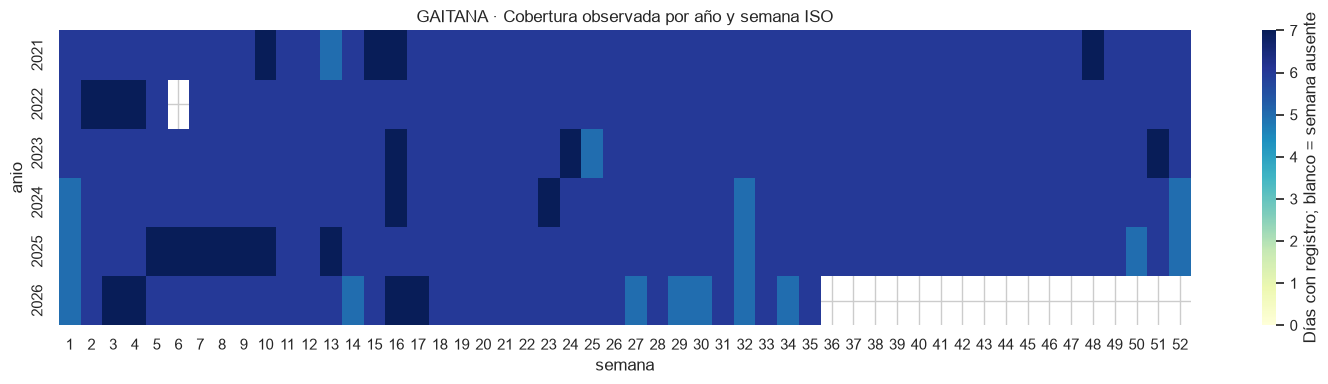

,variable,categoria_original,categoria_mca,tallos,porcentaje
37,color,LIGHT PINK,LIGHT PINK,"37,391,240.000",11.446
34,color,HOT PINK,HOT PINK,"32,950,640.000",10.087
45,color,WHITE,WHITE,"31,976,594.000",9.789
38,color,ORANGE,ORANGE,"28,722,332.000",8.793
42,color,RED,RED,"25,434,078.000",7.786
46,color,YELLOW,YELLOW,"23,503,902.000",7.195
33,color,GREEN,GREEN,"17,922,806.000",5.487
35,color,LAVENDER,LAVENDER,"16,696,392.000",5.111
25,color,BICOLOR PURPLE,BICOLOR PURPLE,"15,613,689.000",4.780
24,color,BICOLOR PINK,BICOLOR PINK,"14,689,799.000",4.497


,K_producto,tallos,registros,porcentaje
0,MINICARNATION,"205,420,928.000",2700363,62.884
1,CARNATION,"60,348,006.000",897629,18.474
2,SOLOMIO,"26,348,705.000",460384,8.066
3,RAFFINE,"18,307,645.000",303527,5.604
4,GREEN BALL,"5,833,428.000",94886,1.786
5,STAR,"4,239,609.000",72063,1.298
6,BARBATUS,"2,184,616.000",38751,0.669
7,VERONICA,"1,681,950.000",28305,0.515
8,VERONICA SPRAY,"699,873.000",11878,0.214
9,AMAZON,"650,527.000",11107,0.199


**Cobertura del análisis.** El MCA utiliza **4,638,217 filas con fecha válida y tallos positivos**, equivalentes a **326,664,331 tallos**, en **6 años ISO**. El producto con mayor masa es **MINICARNATION**, con **62.9 %**. Las categorías con mayor volumen pesan más en el análisis ponderado; esto es intencional porque la unidad de interés es el tallo. Los totales de años parciales no son comparables directamente con años completos.

In [5]:
cobertura = prod.loc[prod.fecha_corte.notna()].groupby(["anio", "semana"]).agg(
    tallos=("tallos", "sum"), registros=("tallos", "size"),
    dias_con_registro=("fecha_corte", lambda s: s.dt.normalize().nunique())
).reset_index()
mostrar("cobertura_semanal", cobertura, n=12)
plt.figure(figsize=(15, 4))
matriz_dias = cobertura.pivot(index="anio", columns="semana", values="dias_con_registro")
sns.heatmap(matriz_dias, cmap="YlGnBu", vmin=0, vmax=7,
            cbar_kws={"label": "Días con registro; blanco = semana ausente"})
plt.title("GAITANA · Cobertura observada por año y semana ISO")
guardar_figura("01_cobertura_semanal")

base_mca, diccionario_categorias = mp.preparar_categorias(prod, UMBRAL_RARO)
mostrar("categorias", diccionario_categorias.sort_values(["variable", "tallos"], ascending=[True, False]), n=18)
mix_producto = base_mca.groupby("K_producto", observed=True).tallos.agg(["sum", "size"])
mix_producto.columns = ["tallos", "registros"]
mix_producto["porcentaje"] = 100 * mix_producto.tallos / mix_producto.tallos.sum()
mix_producto = mix_producto.sort_values("tallos", ascending=False)
mostrar("mix_producto", mix_producto.reset_index())

comentar(
    f"**Cobertura del análisis.** El MCA utiliza **{len(base_mca):,} filas con fecha válida y tallos positivos**, "
    f"equivalentes a **{base_mca.tallos.sum():,.0f} tallos**, en **{base_mca.anio.nunique()} años ISO**. "
    f"El producto con mayor masa es **{mix_producto.index[0]}**, con **{mix_producto.porcentaje.iloc[0]:.1f} %**. "
    "Las categorías con mayor volumen pesan más en el análisis ponderado; esto es intencional porque "
    "la unidad de interés es el tallo. Los totales de años parciales no son comparables directamente con años completos."
)

### 1.1. Auditoría del valor atípico de 2021

Se señala el máximo semanal de 2021 y se muestra el umbral exploratorio `Q3 + 1,5 × IQR` de sus totales semanales. Superar ese umbral no demuestra un error: puede existir estacionalidad.

Se rastrea el pico hasta archivo, hoja y fila del Excel. Los bloques son tramos consecutivos de filas de la misma fuente. Se comparan conservando la multiplicidad por **fecha, producto, color, variedad, invernadero y tallos**, sin usar el supervisor. La coincidencia es una señal de revisión, no una prueba de que dos cosechas sean la misma. Se conservan todas las filas y se muestran escenarios alternativos por separado.

,semana,tallos,registros,umbral_IQR,alerta_IQR
0,1,"1,028,360.000",13444,"1,344,733.625",False
1,2,"991,135.000",13041,"1,344,733.625",False
2,3,"924,981.000",12366,"1,344,733.625",False
3,4,"860,469.000",11647,"1,344,733.625",False
4,5,"834,908.000",11341,"1,344,733.625",False
5,6,"919,187.000",12425,"1,344,733.625",False
6,7,"868,388.000",11780,"1,344,733.625",False
7,8,"711,716.000",9901,"1,344,733.625",False
8,9,"650,197.000",9051,"1,344,733.625",False
9,10,"748,833.000",10464,"1,344,733.625",False


,archivo_origen,hoja_origen,bloque_fuente,fila_inicial,fila_final,registros,tallos
0,Producción Acumulada 2021.xlsx,Sheet1,1,702579,718746,16168,"1,141,430.000"
1,Producción Acumulada 2021.xlsx,Sheet1,2,730505,746672,16168,"1,140,693.000"


,bloque_a,bloque_b,registros_coincidentes,porcentaje_bloque_menor,tallos_coincidentes
0,1,2,16125,99.734,"1,137,253.000"


,escenario,tallos
0,Observado: conservar todos,"2,282,123.000"
1,Hipótesis: bloque 1 es copia,"1,140,693.000"
2,Hipótesis: bloque 2 es copia,"1,141,430.000"


,bloque_fuente,producto,tallos
0,1,BARBATUS,"4,454.000"
1,1,CAMPANULA,420.000
2,1,CARNATION,"194,345.000"
3,1,GREEN BALL,"24,000.000"
4,1,MINICARNATION,"822,560.000"
5,1,RAFFINE,"35,152.000"
6,1,SOLOMIO,"47,785.000"
7,1,STAR,"7,839.000"
8,1,VERONICA,"4,875.000"
9,2,BARBATUS,"4,454.000"


,bloque_fuente,fecha_corte,tallos
0,1,2021-10-18,"208,782.000"
1,1,2021-10-19,"151,541.000"
2,1,2021-10-20,"206,992.000"
3,1,2021-10-21,"179,332.000"
4,1,2021-10-22,"158,354.000"
5,1,2021-10-23,"236,429.000"
6,2,2021-10-18,"208,621.000"
7,2,2021-10-19,"151,491.000"
8,2,2021-10-20,"206,754.000"
9,2,2021-10-21,"179,241.000"


,Finca,Invernadero,Fecha Corte,Hora Corte,Tipo Corte,Año,Semana,Lote,Producto,Grado,Color,Variedad,Tallos,Estado Inventario,columna_sin_encabezado_16,columna_sin_encabezado_17,columna_sin_encabezado_18,archivo_origen,hoja_origen,fila_origen
0,GAITANA,Bloque 13,2021-10-18,,,2021.0,42.0,,Minicarnation,,bicolor pink,Cherry Tessino,80.0,,,,,Producción Acumulada 2021.xlsx,Sheet1,702579
1,GAITANA,Bloque 13,2021-10-18,,,2021.0,42.0,,Minicarnation,,bicolor pink,Cherry Tessino,80.0,,,,,Producción Acumulada 2021.xlsx,Sheet1,702580
2,GAITANA,Bloque 13,2021-10-18,,,2021.0,42.0,,Minicarnation,,bicolor pink,Cherry Tessino,80.0,45109.0,Recepcion,11:36AM,,Producción Acumulada 2021.xlsx,Sheet1,730505
3,GAITANA,Bloque 13,2021-10-18,,,2021.0,42.0,,Minicarnation,,bicolor pink,Cherry Tessino,80.0,45111.0,Recepcion,11:35AM,,Producción Acumulada 2021.xlsx,Sheet1,730506


,finca,invernadero,fecha_corte,hora_corte,tipo_corte,semana,lote,producto,grado,color,variedad,tallos,estado_inventario,anio,tipo_inventario,...,corte_imputado,peso_valido,grado_analisis,grado_metodo,grado_acuerdo_minimo,grado_anios_donantes,grado_registros_donantes,grado_imputado,tipo_corte_analisis,tipo_corte_metodo,tipo_corte_acuerdo_minimo,tipo_corte_anios_donantes,tipo_corte_registros_donantes,tipo_corte_imputado,bloque_fuente
517305,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1
517306,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1
517307,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1
517308,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1
517309,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1
517310,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1
517311,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1
517312,GAITANA,BLOQUE 13,2021-10-18,<NA>,<NA>,42,<NA>,MINICARNATION,<NA>,BICOLOR PINK,CHERRY TESSINO,80.000,<NA>,2021,<NA>,...,False,True,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,SIN_REFERENCIA,sin_referencia,NaN,NaN,NaN,False,1


**Pico de 2021: semana 42**, del 2021-10-18 al 2021-10-23, con **2,282,123 tallos** y **32,336 registros**. Los bloques y sus filas de origen se detallan arriba. Las hipótesis de copia no modifican el total observado ni el análisis principal.

**Posible duplicación.** Entre los bloques 1 y 2 coinciden **16,125 registros** (**99.73 %** del bloque menor), respetando multiplicidades. La evidencia apunta a tres posibilidades: (1) una copia accidental dentro de la misma hoja, (2) una segunda exportación o fotografía operativa de la misma cosecha, enriquecida con identificadores de inventario, o (3) una segunda versión con correcciones. No parece una segunda cosecha independiente porque fecha, producto, color, variedad e invernadero se repiten fila a fila. En las 43 filas restantes, el primer bloque suma 4.177 tallos y el segundo 3.440: hay una diferencia neta de 737 tallos, siempre con 80 tallos en el segundo bloque. Esto prueba que existe una actualización o diferencia de carga, pero no permite decidir cuál cantidad es correcta. El segundo bloque además tiene Estado Inventario informado en las 16.168 filas, mientras el primero no lo tiene. Debe revisarse la procedencia y fecha de exportación antes de eliminar o reemplazar un bloque.

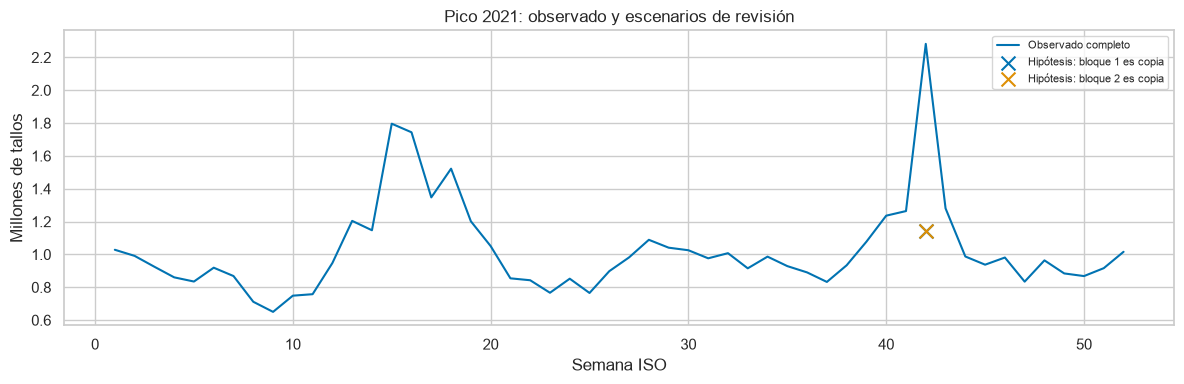

,semana,tallos_semana,mediana_semanas_vecinas_40_44,multiplo_mediana_vecinas,supera_IQR,decision,accion
0,42,"2,282,123.000","1,249,998.000",1.826,True,REVISAR EN ORIGEN antes de usar la semana 42 p...,confirmar si ambos bloques corresponden a cose...


**Decisión sobre la semana irregular.** La semana 42 tiene **1.83 veces** la mediana de sus semanas vecinas (40–44) y **supera** el umbral IQR. Por eso la decisión operativa es: **REVISAR EN ORIGEN antes de usar la semana 42 para decisiones o modelos**. La alerta no autoriza borrar la semana ni convertirla en cero. Primero se debe confirmar en el Excel si los dos bloques son versiones de la misma carga. Hasta esa confirmación, los análisis descriptivos reportan el dato observado y separan este caso como alerta de calidad.

In [6]:
auditoria_2021=ma.auditar_pico_2021(prod)
mostrar("alertas_semanales_2021", auditoria_2021["semanas"], n=60)
if "detalle" in auditoria_2021:
    for clave in ["bloques", "coincidencias", "escenarios", "productos", "dias"]:
        mostrar("pico2021_"+clave, auditoria_2021[clave], n=30)
    detalle_2021=auditoria_2021["detalle"]
    muestras_originales=ma.muestras_fuente(auditoria_2021["bloques"],CARPETA_PRODUCCION,CARPETA_CACHE)
    mostrar("pico2021_muestra_excel", muestras_originales)
    detalle_2021.to_parquet(CARPETA_CACHE/"detalle_pico_2021.parquet", index=False)
    # Exportar las filas completas al Excel, sin truncarlas al número que se muestra.
    mostrar("pico2021_filas", detalle_2021, n=8)
    week=auditoria_2021["semana"]
    pares=auditoria_2021["coincidencias"]
    comentar(
        f"**Pico de 2021: semana {week}**, del {detalle_2021.fecha_corte.min().date()} "
        f"al {detalle_2021.fecha_corte.max().date()}, con **{detalle_2021.tallos.sum():,.0f} tallos** "
        f"y **{len(detalle_2021):,} registros**. Los bloques y sus filas de origen se detallan arriba. "
        "Las hipótesis de copia no modifican el total observado ni el análisis principal."
    )
    if not pares.empty:
        par=pares.loc[pares.porcentaje_bloque_menor.idxmax()]
        comentar(
            f"**Posible duplicación.** Entre los bloques {int(par.bloque_a)} y {int(par.bloque_b)} "
            f"coinciden **{int(par.registros_coincidentes):,} registros** "
            f"(**{par.porcentaje_bloque_menor:.2f} %** del bloque menor), respetando multiplicidades. "
            "La evidencia apunta a tres posibilidades: (1) una copia accidental dentro de la misma hoja, "
            "(2) una segunda exportación o fotografía operativa de la misma cosecha, enriquecida con "
            "identificadores de inventario, o (3) una segunda versión con correcciones. "
            "No parece una segunda cosecha independiente porque fecha, producto, color, variedad e "
            "invernadero se repiten fila a fila. En las 43 filas restantes, el primer bloque suma "
            "4.177 tallos y el segundo 3.440: hay una diferencia neta de 737 tallos, siempre con "
            "80 tallos en el segundo bloque. Esto prueba que existe una actualización o diferencia de "
            "carga, pero no permite decidir cuál cantidad es correcta. El segundo bloque además tiene "
            "Estado Inventario informado en las 16.168 filas, mientras el primero no lo tiene. "
            "Debe revisarse la procedencia y fecha de exportación antes de eliminar o reemplazar un bloque."
        )
    fig,ax=plt.subplots(figsize=(12,4))
    weekly=auditoria_2021["semanas"]
    ax.plot(weekly.semana,weekly.tallos/1e6,label="Observado completo")
    for i,row in auditoria_2021["escenarios"].iloc[1:].iterrows():
        ax.scatter([week],[row.tallos/1e6],marker="x",s=100,label=row.escenario)
    ax.set(title="Pico 2021: observado y escenarios de revisión",xlabel="Semana ISO",ylabel="Millones de tallos")
    ax.legend(fontsize=8); guardar_figura("01b_auditoria_pico_2021")
    # Regla de decisión explícita: separar alerta estadística de decisión de depuración.
    vecinos=auditoria_2021["semanas"].loc[auditoria_2021["semanas"].semana.between(40,44)].copy()
    mediana_vecinos=vecinos.loc[vecinos.semana.ne(week),"tallos"].median()
    ratio=float(vecinos.loc[vecinos.semana.eq(week),"tallos"].iloc[0]/mediana_vecinos)
    alerta_iqr=bool(vecinos.loc[vecinos.semana.eq(week),"alerta_IQR"].iloc[0])
    decision=("REVISAR EN ORIGEN antes de usar la semana 42 para decisiones o modelos"
              if alerta_iqr and ratio>=1.5 else
              "conservar como observada y monitorear")
    mostrar("decision_pico_2021",pd.DataFrame([{
        "semana":week,"tallos_semana":float(vecinos.loc[vecinos.semana.eq(week),"tallos"].iloc[0]),
        "mediana_semanas_vecinas_40_44":float(mediana_vecinos),
        "multiplo_mediana_vecinas":ratio,"supera_IQR":alerta_iqr,
        "decision":decision,
        "accion":("confirmar si ambos bloques corresponden a cosechas distintas; si no, corregir la fuente y regenerar resultados"
                   if "REVISAR" in decision else "mantener y documentar")
    }]))
    comentar(
        f"**Decisión sobre la semana irregular.** La semana {week} tiene **{ratio:.2f} veces** "
        f"la mediana de sus semanas vecinas (40–44) y **{'supera' if alerta_iqr else 'no supera'}** el umbral IQR. "
        f"Por eso la decisión operativa es: **{decision}**. "
        "La alerta no autoriza borrar la semana ni convertirla en cero. Primero se debe confirmar en el Excel "
        "si los dos bloques son versiones de la misma carga. Hasta esa confirmación, los análisis descriptivos "
        "reportan el dato observado y separan este caso como alerta de calidad."
    )
# Base enriquecida: originales, imputaciones y alertas. Todas las filas limpias permanecen.
prod.to_parquet(CARPETA_CACHE/"produccion_gaitana_auditada.parquet", index=False)

## 2. Variables y diagnóstico antes del mapa

**Análisis principal:** producto y color activos. Con dos variables, este ajuste es el caso bivariado del MCA, estrechamente relacionado con el AC de la tabla producto–color; sirve como referencia del catálogo, no como una explicación multivariable completa. Describe toda la producción con fecha válida y peso positivo. No usa grado o corte para construir sus ejes, porque sus faltantes cambian entre años. Los ajustes con grado o semana incorporan tres variables activas.

**Suplementarias:** semana ISO, año ISO, grado comercial, corte, invernadero y variedad. Su proyección permite interpretar el mapa sin obligarlo a separar esas categorías. Los faltantes se identifican como `SIN_DATO`, no como una categoría agronómica real.

**Segundo MCA:** incorpora grado como activo exclusivamente donde está registrado. Se comparará su cobertura y sensibilidad. **Semana activa** se probará aparte: su orden no interviene en el MCA estándar y 52–53 niveles pueden ocupar muchos ejes.

No se incluyen variedad y producto simultáneamente como activos por defecto: el catálogo puede hacerlos casi deterministas. La V de Cramér se usa aquí como magnitud descriptiva, ponderada por tallos; no se calculan p-valores suponiendo millones de tallos independientes.

,variable,K_producto,K_color,K_grado,K_tipo_corte,K_semana,K_anio
0,K_producto,NaN,0.298,0.331,0.107,0.021,0.075
1,K_color,0.298,NaN,0.065,0.058,0.029,0.074
2,K_grado,0.331,0.065,NaN,0.207,0.157,0.423
3,K_tipo_corte,0.107,0.058,0.207,NaN,0.104,0.420
4,K_semana,0.021,0.029,0.157,0.104,NaN,0.133
5,K_anio,0.075,0.074,0.423,0.420,0.133,NaN


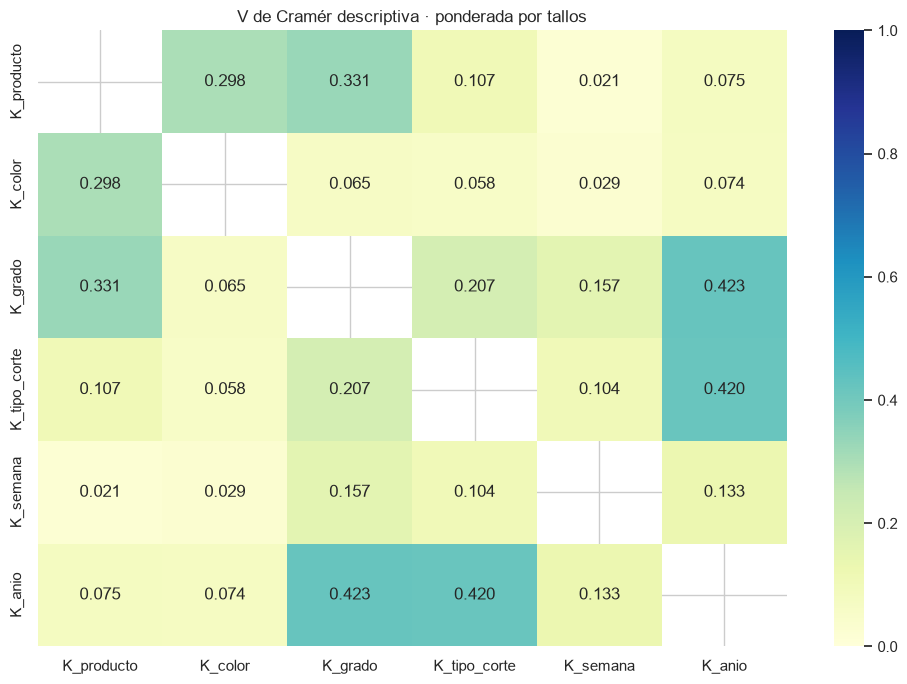

**Diagnóstico.** La asociación más alta de esta matriz es **K_grado–K_anio**, con **V = 0.423**. Entre producto y color es **0.298**; entre semana y producto, **0.021**. V describe una relación global, no su causa ni su estabilidad anual. Las asociaciones con SIN_DATO pueden reflejar cambios de registro. Para semana, agrupar todos los años puede diluir patrones distintos o confundirlos con diferencias de cobertura: se revisará su recurrencia explícitamente.

In [7]:
ACTIVAS = ["K_producto", "K_color"]
SUPLEMENTARIAS = ["K_semana", "K_anio", "K_grado", "K_tipo_corte", "K_invernadero", "K_variedad"]
variables_diag = ACTIVAS + ["K_grado", "K_tipo_corte", "K_semana", "K_anio"]
diag = pd.DataFrame(index=variables_diag, columns=variables_diag, dtype=float)
for i, a in enumerate(variables_diag):
    for b in variables_diag[i+1:]:
        diag.loc[a,b] = diag.loc[b,a] = mp.cramer(mp.tabla_pesos(base_mca,a,b))
mostrar("asociaciones", diag.reset_index(names="variable"))
plt.figure(figsize=(10, 7))
sns.heatmap(diag, annot=True, fmt=".3f", vmin=0, vmax=1, cmap="YlGnBu")
plt.title("V de Cramér descriptiva · ponderada por tallos")
guardar_figura("02_asociaciones")

pares = [(a,b,diag.loc[a,b]) for i,a in enumerate(variables_diag) for b in variables_diag[i+1:]
         if pd.notna(diag.loc[a,b])]
mayor = max(pares, key=lambda x: x[2])
comentar(
    f"**Diagnóstico.** La asociación más alta de esta matriz es **{mayor[0]}–{mayor[1]}**, "
    f"con **V = {mayor[2]:.3f}**. Entre producto y color es **{diag.loc['K_producto','K_color']:.3f}**; "
    f"entre semana y producto, **{diag.loc['K_semana','K_producto']:.3f}**. "
    "V describe una relación global, no su causa ni su estabilidad anual. Las asociaciones con SIN_DATO "
    "pueden reflejar cambios de registro. Para semana, agrupar todos los años puede diluir patrones "
    "distintos o confundirlos con diferencias de cobertura: se revisará su recurrencia explícitamente."
)

## 3. MCA principal: ajuste y validaciones

La indicadora contiene una columna por categoría activa. Cada registro contribuye en proporción a sus tallos. Se agrupan perfiles idénticos y se descompone la matriz de productos `SᵀS` de los residuos estandarizados; así no es necesario expandir millones de tallos ni conservar una indicadora densa de todas las filas.

Se comprueba la inercia total `(J − Q) / Q`, la suma de contribuciones por eje y el centrado de coordenadas. Se muestran inercia cruda y correcciones de Benzécri y Greenacre. Las coordenadas del mapa corresponden al MCA original; la corrección solo cambia cómo se comunica la inercia. Las fórmulas y el código numérico están en `scripts/mca_produccion.py`.

,dimension,autovalor,cruda_pct,benzecri_pct,greenacre_pct,greenacre_acumulada_pct
0,Dim1,0.782,4.888,29.846,29.846,29.846
1,Dim2,0.772,4.822,27.655,27.655,57.502
2,Dim3,0.701,4.379,15.093,15.093,72.594
3,Dim4,0.656,4.100,9.120,9.120,81.714
4,Dim5,0.639,3.995,7.270,7.270,88.984
5,Dim6,0.625,3.906,5.851,5.851,94.835
6,Dim7,0.601,3.757,3.836,3.836,98.671
7,Dim8,0.546,3.410,0.782,0.782,99.454


,variable,categoria,masa_pct,Dim1,contrib_Dim1_pct,cos2_Dim1,Dim2,contrib_Dim2_pct,cos2_Dim2,Dim3,contrib_Dim3_pct,cos2_Dim3,Dim4,contrib_Dim4_pct,cos2_Dim4,Dim5,contrib_Dim5_pct,cos2_Dim5,Dim6,contrib_Dim6_pct,cos2_Dim6,Dim7,contrib_Dim7_pct,cos2_Dim7,Dim8,contrib_Dim8_pct,cos2_Dim8,cos2_plano
3,K_producto,GREEN BALL,0.893,6.215,44.098,0.702,1.957,4.432,0.070,0.119,0.018,0.000,0.420,0.240,0.003,-0.072,0.007,0.000,0.329,0.154,0.002,-0.187,0.052,0.001,0.144,0.034,0.000,0.772
22,K_color,GREEN,2.743,3.506,43.121,0.714,1.063,4.016,0.066,0.048,0.009,0.000,0.131,0.072,0.001,-0.020,0.002,0.000,0.082,0.030,0.000,-0.038,0.007,0.000,0.013,0.001,0.000,0.779
6,K_producto,RAFFINE,2.802,-1.226,5.381,0.089,3.341,40.532,0.663,-0.145,0.084,0.001,0.060,0.015,0.000,-0.268,0.315,0.004,0.368,0.606,0.008,-0.189,0.166,0.002,-0.131,0.088,0.001,0.752
13,K_color,BICOLOR BURGUNDY,1.089,-1.670,3.884,0.062,4.696,31.131,0.491,0.005,0.000,0.000,-0.498,0.411,0.006,0.386,0.254,0.003,0.814,1.154,0.015,-0.747,1.010,0.012,-1.119,2.498,0.028,0.553
15,K_color,BICOLOR PURPLE,2.390,-0.635,1.231,0.020,1.415,6.203,0.101,-0.331,0.374,0.006,0.276,0.278,0.004,-0.398,0.591,0.008,-0.665,1.691,0.022,1.131,5.086,0.064,0.152,0.102,0.001,0.121
25,K_color,LIGHT PINK,5.723,-0.324,0.770,0.014,0.284,0.597,0.010,-0.108,0.096,0.002,0.006,0.000,0.000,-0.717,4.605,0.066,0.174,0.278,0.004,-0.360,1.234,0.017,0.328,1.130,0.014,0.024
32,K_color,WHITE,4.894,-0.248,0.386,0.007,0.120,0.092,0.002,0.626,2.738,0.043,-0.210,0.329,0.005,-0.064,0.031,0.000,-0.461,1.662,0.023,0.297,0.719,0.010,1.218,13.317,0.161,0.008
14,K_color,BICOLOR PINK,2.248,-0.307,0.272,0.004,-0.082,0.020,0.000,-0.721,1.668,0.024,2.750,25.922,0.356,1.846,11.992,0.161,0.272,0.267,0.003,-0.199,0.147,0.002,0.292,0.353,0.004,0.005
8,K_producto,STAR,0.649,-0.455,0.172,0.003,-0.176,0.026,0.000,-1.437,1.913,0.027,5.806,33.354,0.443,3.628,13.359,0.173,-0.050,0.003,0.000,0.519,0.291,0.004,0.263,0.082,0.001,0.003
11,K_producto,VERONICA,0.257,-0.519,0.089,0.001,0.047,0.001,0.000,6.048,13.441,0.189,1.874,1.379,0.018,-1.621,1.058,0.014,-0.938,0.363,0.005,-0.558,0.133,0.002,3.339,5.261,0.058,0.001


Perfiles agregados: 108 | Variables activas: 2 | Categorías: 34
Validaciones numéricas: inercia total, contribuciones y centrado correctos.


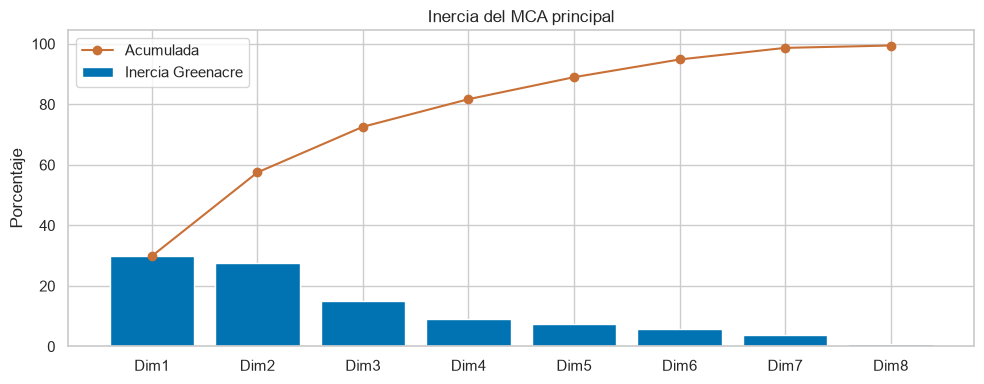

**Dimensionalidad.** El plano 1–2 recoge **9.7 % de inercia cruda** y **57.5 % según Greenacre**. La corrección no convierte el mapa en una explicación causal ni garantiza que todas sus categorías estén bien representadas. Para interpretar un punto revisaremos su cos² y su contribución, incluyendo los ejes 3–4 cuando el primer plano sea insuficiente.

**Decisión para las suplementarias.** Semana, año, variedad, invernadero, grado y corte sirven para explicar quién ocupa cada perfil, pero no alteran los ejes del MCA principal. Si una categoría aparece muy alejada, se debe comprobar primero su cos² y su volumen. Si aparece cerca del origen, no hay evidencia de un perfil propio en este plano. La siguiente decisión analítica es usar semana como activa solo en el modelo de sensibilidad, porque hacerlo puede repartir la inercia entre 52 niveles y volver menos estable la lectura del producto y el color.

**Lectura ejecutiva del mapa principal.** Las categorías que más construyen Dim1 son K_producto=GREEN BALL, K_color=GREEN, K_producto=RAFFINE, K_color=BICOLOR BURGUNDY, K_color=BICOLOR PURPLE. Las categorías mejor representadas en el plano son K_color=GREEN, K_producto=GREEN BALL, K_producto=RAFFINE, K_color=BICOLOR BURGUNDY, K_producto=MINICARNATION. Para gerencia, la primera lista indica qué perfiles explican la separación del mapa; la segunda indica dónde la lectura del plano es confiable. Una categoría cercana al origen no es necesariamente irrelevante: puede ser frecuente y poco diferenciadora. La acción recomendada es priorizar las categorías con alta contribución y cos², y consultar la tabla completa antes de intervenir sobre las demás.

In [8]:
mca = mp.ajustar_mca(base_mca, ACTIVAS)
categorias = mp.resultados_categorias(mca)
n = mca["n_dim"]
inercia = pd.DataFrame({
    "dimension": [f"Dim{k+1}" for k in range(n)], "autovalor": mca["eig"][:n],
    "cruda_pct": mca["inercia_cruda_pct"][:n],
    "benzecri_pct": mca["inercia_benzecri_pct"][:n],
    "greenacre_pct": mca["inercia_greenacre_pct"][:n]
})
inercia["greenacre_acumulada_pct"] = inercia.greenacre_pct.cumsum()
mostrar("inercia_principal", inercia)
mostrar("coordenadas_principales", categorias.sort_values("contrib_Dim1_pct", ascending=False))
print("Perfiles agregados:", len(mca["perfiles"]), "| Variables activas:", mca["Q"], "| Categorías:", mca["J"])
print("Validaciones numéricas: inercia total, contribuciones y centrado correctos.")

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(inercia.dimension, inercia.greenacre_pct, label="Inercia Greenacre")
ax.plot(inercia.dimension, inercia.greenacre_acumulada_pct, marker="o", color="#c97036", label="Acumulada")
ax.set(ylabel="Porcentaje", title="Inercia del MCA principal")
ax.legend()
guardar_figura("03_inercia_mca")

comentar(
    f"**Dimensionalidad.** El plano 1–2 recoge **{inercia.cruda_pct.iloc[:2].sum():.1f} % de inercia cruda** "
    f"y **{inercia.greenacre_pct.iloc[:2].sum():.1f} % según Greenacre**. "
    "La corrección no convierte el mapa en una explicación causal ni garantiza que todas sus categorías "
    "estén bien representadas. Para interpretar un punto revisaremos su cos² y su contribución, "
    "incluyendo los ejes 3–4 cuando el primer plano sea insuficiente."
)
comentar(
    "**Decisión para las suplementarias.** Semana, año, variedad, invernadero, grado y corte sirven para "
    "explicar quién ocupa cada perfil, pero no alteran los ejes del MCA principal. Si una categoría aparece "
    "muy alejada, se debe comprobar primero su cos² y su volumen. Si aparece cerca del origen, no hay evidencia "
    "de un perfil propio en este plano. La siguiente decisión analítica es usar semana como activa solo en el "
    "modelo de sensibilidad, porque hacerlo puede repartir la inercia entre 52 niveles y volver menos estable "
    "la lectura del producto y el color."
)
top_contrib=categorias.nlargest(5,"contrib_Dim1_pct")
top_cos=categorias.nlargest(5,"cos2_plano")
comentar(
    "**Lectura ejecutiva del mapa principal.** Las categorías que más construyen Dim1 son "
    + ", ".join(f"{r.variable}={r.categoria}" for _,r in top_contrib.iterrows())
    + ". Las categorías mejor representadas en el plano son "
    + ", ".join(f"{r.variable}={r.categoria}" for _,r in top_cos.iterrows())
    + ". Para gerencia, la primera lista indica qué perfiles explican la separación del mapa; la segunda "
    + "indica dónde la lectura del plano es confiable. Una categoría cercana al origen no es necesariamente "
    + "irrelevante: puede ser frecuente y poco diferenciadora. La acción recomendada es priorizar las categorías "
    + "con alta contribución y cos², y consultar la tabla completa antes de intervenir sobre las demás."
)

### 3.1. Mapas y significado de los ejes

**Contribución:** cuánto ayuda una categoría a construir un eje. **cos²:** qué parte de su distancia al origen se representa en el plano. Un punto lejano con cos² bajo en el plano elegido no debe interpretarse solo por su apariencia. Solo se rotulan las categorías más contribuyentes para evitar un mapa ilegible; todas se exportan a Excel.

El signo de los ejes es arbitrario. Cercanía entre categorías de variables distintas sugiere perfiles relacionados, pero no prueba una relación causal ni una equivalencia entre categorías.

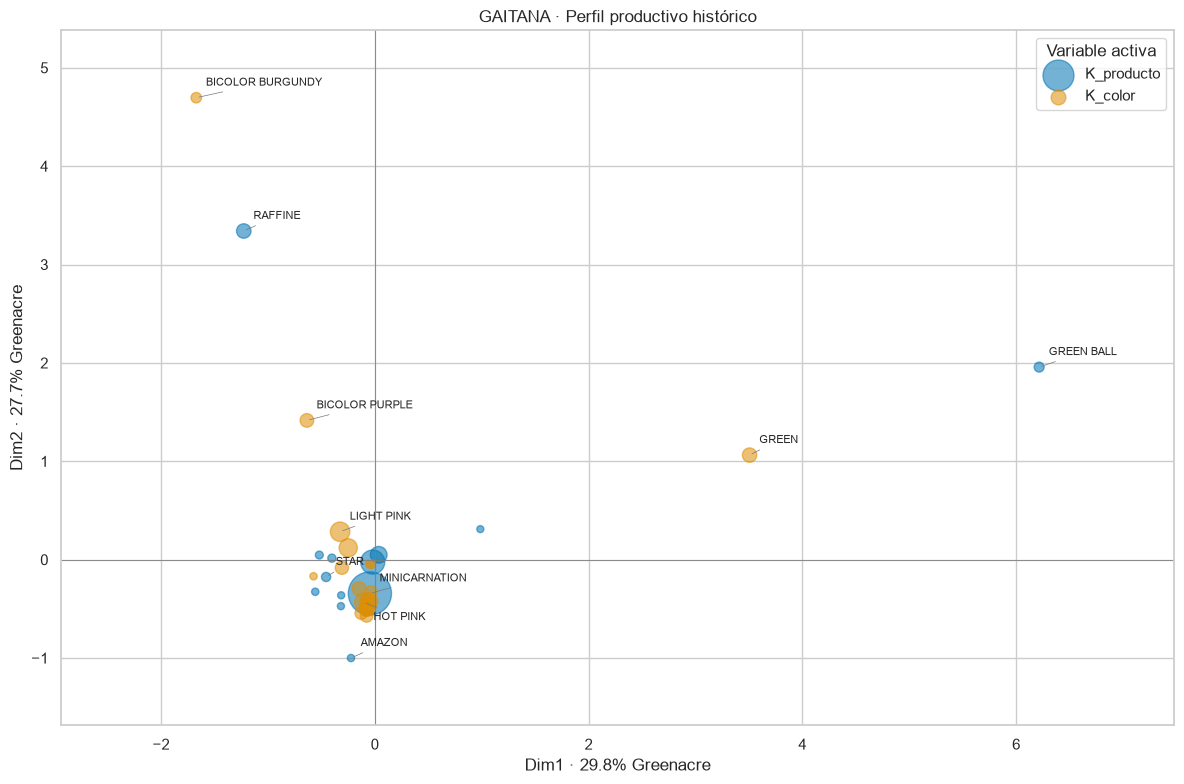

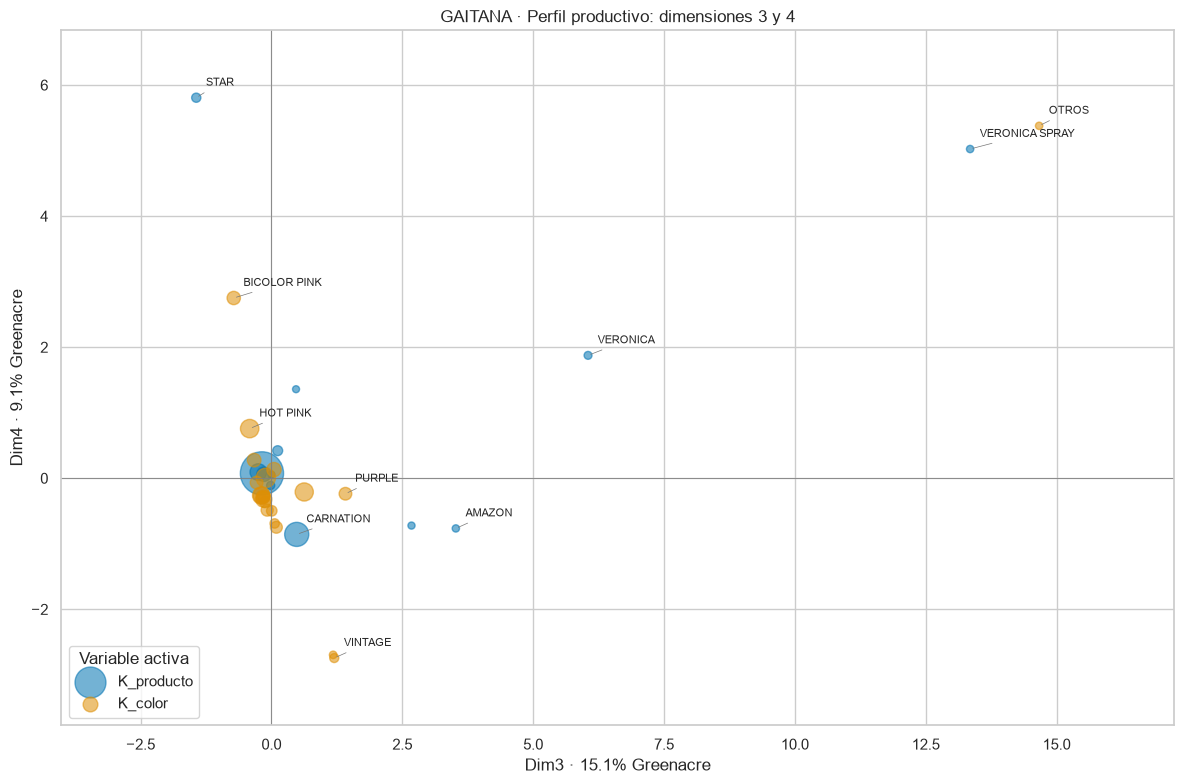

,variable,contrib_Dim1_pct,contrib_Dim2_pct,contrib_Dim3_pct,contrib_Dim4_pct
0,K_color,50.000,50.000,50.000,50.000
1,K_producto,50.000,50.000,50.000,50.000


**Dimensión 1.** La variable que más contribuye es **K_color (50.0 %)**. Las categorías que más construyen el eje son **K_producto=GREEN BALL** (44.1 %); **K_color=GREEN** (43.1 %); **K_producto=RAFFINE** (5.4 %); **K_color=BICOLOR BURGUNDY** (3.9 %); **K_color=BICOLOR PURPLE** (1.2 %). Estos nombres describen el contraste del catálogo; no son una clasificación de calidad de las flores.

**Contraste del eje 1.** En el lado positivo destacan K_producto=GREEN BALL, K_color=GREEN, K_producto=OTROS; en el negativo, K_producto=RAFFINE, K_color=BICOLOR BURGUNDY, K_color=BICOLOR PURPLE. El contraste expresa perfiles de coocurrencia. El signo podría invertirse sin cambiar el resultado.

**Dimensión 2.** La variable que más contribuye es **K_producto (50.0 %)**. Las categorías que más construyen el eje son **K_producto=RAFFINE** (40.5 %); **K_color=BICOLOR BURGUNDY** (31.1 %); **K_color=BICOLOR PURPLE** (6.2 %); **K_producto=MINICARNATION** (4.8 %); **K_producto=GREEN BALL** (4.4 %). Estos nombres describen el contraste del catálogo; no son una clasificación de calidad de las flores.

**Contraste del eje 2.** En el lado positivo destacan K_producto=RAFFINE, K_color=BICOLOR BURGUNDY, K_color=BICOLOR PURPLE; en el negativo, K_producto=MINICARNATION, K_color=HOT PINK, K_color=YELLOW. El contraste expresa perfiles de coocurrencia. El signo podría invertirse sin cambiar el resultado.

**Representación de categorías.** 4 de 34 categorías tienen al menos la mitad de su distancia al origen representada en el plano 1–2. Para las demás, la tabla completa y los ejes adicionales son necesarios antes de interpretar cercanías.

In [9]:
def mapa_mca(modelo, titulo, nombre, ejes=(0,1)):
    if len(modelo["eig"]) <= max(ejes):
        print("No hay dimensiones suficientes para este plano.")
        return
    x,y=ejes
    cat=mp.resultados_categorias(modelo)
    paleta=dict(zip(modelo["activas"], sns.color_palette("colorblind", len(modelo["activas"]))))
    fig,ax=plt.subplots(figsize=(12,8))
    ax.axhline(0,color="gray",linewidth=.6); ax.axvline(0,color="gray",linewidth=.6)
    etiquetas=[]
    for variable,color in paleta.items():
        sub=cat.loc[cat.variable.eq(variable)]
        ax.scatter(sub[f"Dim{x+1}"],sub[f"Dim{y+1}"],s=25+sub.masa_pct*30,
                   alpha=.55,label=variable,color=color)
        score=sub[f"contrib_Dim{x+1}_pct"]+sub[f"contrib_Dim{y+1}_pct"]
        for _,row in sub.loc[score.nlargest(5).index].iterrows():
            etiquetas.append((row[f"Dim{x+1}"],row[f"Dim{y+1}"],row.categoria))
    mp.etiquetar_mapa(ax,etiquetas)
    ax.set(title=titulo, xlabel=f"Dim{x+1} · {modelo['inercia_greenacre_pct'][x]:.1f}% Greenacre",
           ylabel=f"Dim{y+1} · {modelo['inercia_greenacre_pct'][y]:.1f}% Greenacre")
    ax.legend(title="Variable activa")
    guardar_figura(nombre)

mapa_mca(mca,"GAITANA · Perfil productivo histórico", "04_mapa_principal")
mapa_mca(mca,"GAITANA · Perfil productivo: dimensiones 3 y 4", "05_mapa_dimensiones_3_4",(2,3))

aportes = categorias.groupby("variable")[[f"contrib_Dim{k+1}_pct" for k in range(min(4,n))]].sum()
mostrar("aportes_variables", aportes.reset_index())
for eje in [1,2]:
    col=f"contrib_Dim{eje}_pct"
    top=categorias.nlargest(5,col)
    comentar(
        f"**Dimensión {eje}.** La variable que más contribuye es **{aportes[col].idxmax()} "
        f"({aportes[col].max():.1f} %)**. Las categorías que más construyen el eje son "
        + "; ".join(f"**{r.variable}={r.categoria}** ({r[col]:.1f} %)" for _,r in top.iterrows())
        + ". Estos nombres describen el contraste del catálogo; no son una clasificación de calidad de las flores."
    )
    positivos=categorias.loc[categorias[f"Dim{eje}"]>0].nlargest(3,col)
    negativos=categorias.loc[categorias[f"Dim{eje}"]<0].nlargest(3,col)
    comentar(
        f"**Contraste del eje {eje}.** En el lado positivo destacan "
        + ", ".join(positivos.variable+"="+positivos.categoria)
        + "; en el negativo, "+", ".join(negativos.variable+"="+negativos.categoria)
        + ". El contraste expresa perfiles de coocurrencia. El signo podría invertirse sin cambiar el resultado."
    )
comentar(
    f"**Representación de categorías.** {int((categorias.cos2_plano>=.5).sum())} de {len(categorias)} categorías "
    "tienen al menos la mitad de su distancia al origen representada en el plano 1–2. "
    "Para las demás, la tabla completa y los ejes adicionales son necesarios antes de interpretar cercanías."
)

## 4. Grado, corte, variedad y año como información suplementaria

La proyección usa los perfiles de las filas que pertenecen a cada categoría, ponderados por tallos. Una categoría suplementaria no aporta a la inercia del ajuste principal. Se mantienen todas las variedades en la tabla, aunque solo unas pocas se rotulen en un gráfico.

,variable,categoria,tallos,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8
0,K_semana,S01,"6,405,786.000",0.037,-0.042,-0.013,-0.000,0.005,-0.033,0.002,0.029
1,K_semana,S02,"6,536,202.000",0.044,-0.046,-0.017,-0.002,0.009,-0.035,-0.000,0.035
2,K_semana,S03,"6,415,012.000",0.016,-0.072,-0.025,-0.005,0.028,-0.062,0.029,0.031
3,K_semana,S04,"6,984,455.000",-0.006,-0.065,-0.011,0.004,-0.003,-0.037,0.014,0.027
4,K_semana,S05,"6,117,028.000",0.022,-0.030,0.003,-0.009,-0.003,-0.022,0.014,0.025
5,K_semana,S06,"5,303,372.000",-0.004,-0.024,0.029,-0.029,0.033,-0.052,0.034,0.006
6,K_semana,S07,"6,142,103.000",0.013,-0.019,0.012,-0.019,0.012,-0.019,0.009,0.006
7,K_semana,S08,"5,976,204.000",-0.021,0.007,0.014,-0.026,0.022,-0.019,0.021,-0.015
8,K_semana,S09,"5,869,028.000",-0.030,-0.007,0.028,-0.035,0.031,-0.016,0.028,-0.023
9,K_semana,S10,"6,586,101.000",-0.024,-0.016,0.017,-0.006,0.009,0.018,0.017,-0.026


,variable,categoria,tallos,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8
58,K_grado,CINTA AMARILLA,"5,618,295.000",-0.051,-0.272,-0.154,0.106,-0.289,0.140,-0.177,0.078
59,K_grado,CINTA BLANCA,"3,142,980.000",-0.090,-0.292,-0.024,-0.077,0.011,0.088,-0.176,0.050
60,K_grado,CINTA NARANJA,"5,894,120.000",-0.086,-0.297,-0.110,-0.006,-0.158,0.096,-0.241,0.079
61,K_grado,CINTA NEGRA,"2,510,254.000",-0.011,-0.065,0.297,-0.725,1.012,-0.375,0.054,-0.004
62,K_grado,CINTA VERDE,"16,226,453.000",-0.052,-0.280,-0.124,0.011,-0.322,0.095,-0.141,0.061
63,K_grado,FCY,"548,834.000",-0.056,-0.281,-0.099,-0.036,-0.233,0.082,-0.149,0.051
64,K_grado,GRANEL,"205,217,539.000",-0.021,0.072,0.047,-0.005,0.058,-0.033,0.056,-0.011
65,K_grado,NACIONAL,"414,122.000",-0.330,-0.326,0.403,0.349,-0.755,1.237,-0.239,1.765
66,K_grado,OTROS,"490,929.000",0.729,0.560,0.000,0.141,0.003,-0.190,0.335,0.339
67,K_grado,SIN_DATO,"86,600,805.000",0.070,-0.068,-0.080,0.026,-0.072,0.048,-0.073,-0.009


,variable,categoria,tallos,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8
52,K_anio,2021,"53,374,645.000",0.064,-0.106,-0.091,0.010,-0.052,0.042,-0.087,-0.036
53,K_anio,2022,"48,704,873.000",0.078,0.005,-0.057,0.027,-0.074,0.064,-0.055,0.013
54,K_anio,2023,"57,341,913.000",0.021,0.075,-0.003,-0.040,0.097,0.002,-0.012,0.007
55,K_anio,2024,"58,544,513.000",-0.029,0.036,-0.007,0.002,0.028,-0.032,0.012,0.012
56,K_anio,2025,"61,349,519.000",-0.038,-0.006,0.067,-0.008,0.009,-0.029,0.054,0.015
57,K_anio,2026,"47,348,868.000",-0.092,-0.013,0.088,0.016,-0.029,-0.039,0.084,-0.016


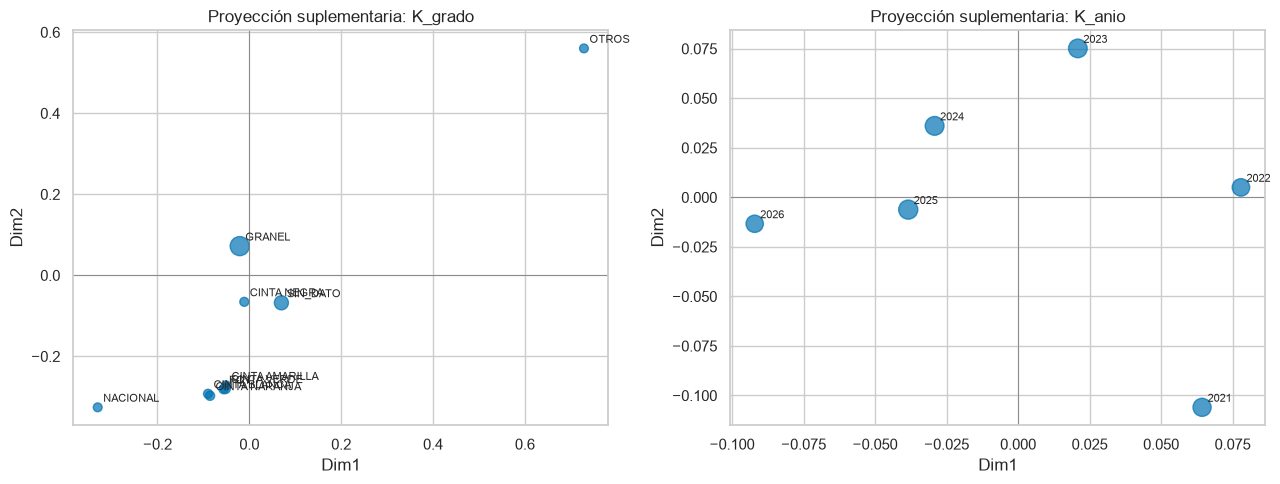

**Cómo leer estas proyecciones.** Si un grado aparece hacia el mismo lado que un producto o color, sus filas comparten parte del perfil descrito por ese eje. Eso no demuestra una relación causal. La posición de **SIN_DATO** informa sobre el registro, no sobre la flor. Las diferencias entre años también pueden reflejar cambios de catálogo, cobertura o criterios comerciales. Variedad e invernadero se conservan como detalle suplementario para investigar esas diferencias.

In [10]:
suplementarias = pd.concat([
    mp.proyectar_suplementaria(base_mca,mca,col) for col in SUPLEMENTARIAS
], ignore_index=True)
mostrar("suplementarias", suplementarias, n=15)
mostrar("grados_proyectados", suplementarias.loc[suplementarias.variable.eq("K_grado")])
mostrar("anios_proyectados", suplementarias.loc[suplementarias.variable.eq("K_anio")])

fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,var in zip(axes,["K_grado","K_anio"]):
    sub=suplementarias.loc[suplementarias.variable.eq(var)]
    ax.axhline(0,color="gray",lw=.6);ax.axvline(0,color="gray",lw=.6)
    ax.scatter(sub.Dim1,sub.Dim2,s=40+150*sub.tallos/sub.tallos.max(),alpha=.7)
    for _,r in sub.iterrows():ax.annotate(r.categoria,(r.Dim1,r.Dim2),xytext=(4,4),textcoords="offset points",fontsize=8)
    ax.set(title=f"Proyección suplementaria: {var}",xlabel="Dim1",ylabel="Dim2")
guardar_figura("06_grado_anio_suplementarios")

comentar(
    "**Cómo leer estas proyecciones.** Si un grado aparece hacia el mismo lado que un producto o color, "
    "sus filas comparten parte del perfil descrito por ese eje. Eso no demuestra una relación causal. "
    "La posición de **SIN_DATO** informa sobre el registro, no sobre la flor. Las diferencias entre años "
    "también pueden reflejar cambios de catálogo, cobertura o criterios comerciales. "
    "Variedad e invernadero se conservan como detalle suplementario para investigar esas diferencias."
)

## 5. Semana ISO: trayectoria temporal y comparación entre años

La semana es una categoría **ordenada y cíclica**: después de la última semana del año viene la primera. El MCA ordinario no usa esa distancia temporal. Por eso la semana se proyecta sin construir los ejes y después se presenta en su orden cronológico. La línea entre semanas es una ayuda de lectura; no es un ajuste ni una trayectoria de individuos.

La semana 53 se conserva cuando existe. Para comparar años se utilizan semanas comunes: la misma etiqueta ISO no equivale siempre a las mismas fechas de fiestas o decisiones comerciales.

,variable,categoria,tallos,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8
0,K_semana,S01,"6,405,786.000",0.037,-0.042,-0.013,-0.000,0.005,-0.033,0.002,0.029
1,K_semana,S02,"6,536,202.000",0.044,-0.046,-0.017,-0.002,0.009,-0.035,-0.000,0.035
2,K_semana,S03,"6,415,012.000",0.016,-0.072,-0.025,-0.005,0.028,-0.062,0.029,0.031
3,K_semana,S04,"6,984,455.000",-0.006,-0.065,-0.011,0.004,-0.003,-0.037,0.014,0.027
4,K_semana,S05,"6,117,028.000",0.022,-0.030,0.003,-0.009,-0.003,-0.022,0.014,0.025
5,K_semana,S06,"5,303,372.000",-0.004,-0.024,0.029,-0.029,0.033,-0.052,0.034,0.006
6,K_semana,S07,"6,142,103.000",0.013,-0.019,0.012,-0.019,0.012,-0.019,0.009,0.006
7,K_semana,S08,"5,976,204.000",-0.021,0.007,0.014,-0.026,0.022,-0.019,0.021,-0.015
8,K_semana,S09,"5,869,028.000",-0.030,-0.007,0.028,-0.035,0.031,-0.016,0.028,-0.023
9,K_semana,S10,"6,586,101.000",-0.024,-0.016,0.017,-0.006,0.009,0.018,0.017,-0.026


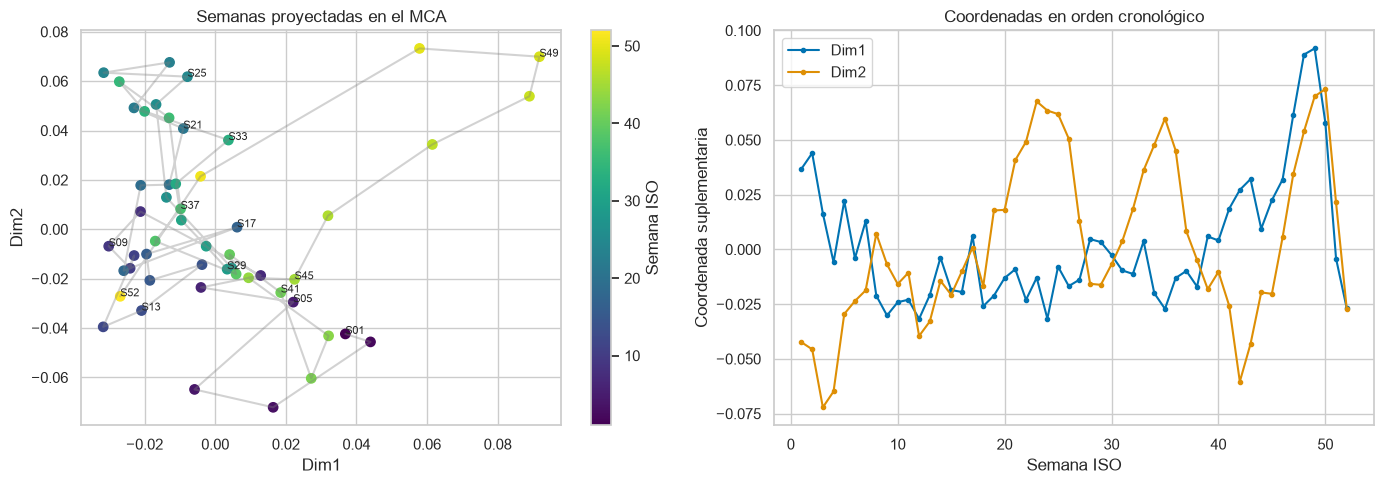

,variable,categoria,tallos,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,anio,semana
0,K_anio_semana,2021-S01,"1,028,360.000",0.071,-0.183,-0.114,-0.014,-0.036,0.004,-0.063,-0.074,2021,1
1,K_anio_semana,2021-S02,"991,135.000",0.025,-0.184,-0.109,-0.017,-0.036,-0.005,-0.037,-0.057,2021,2
2,K_anio_semana,2021-S03,"924,981.000",0.020,-0.147,-0.100,-0.023,-0.039,-0.007,-0.026,-0.050,2021,3
3,K_anio_semana,2021-S04,"860,469.000",-0.006,-0.169,-0.115,0.007,-0.063,0.030,-0.067,-0.036,2021,4
4,K_anio_semana,2021-S05,"834,908.000",0.016,-0.122,-0.085,-0.026,-0.002,-0.006,-0.030,-0.049,2021,5
5,K_anio_semana,2021-S06,"919,187.000",-0.008,-0.163,-0.096,-0.019,-0.023,0.016,-0.054,-0.064,2021,6
6,K_anio_semana,2021-S07,"868,388.000",0.008,-0.165,-0.094,-0.017,-0.023,0.039,-0.081,-0.050,2021,7
7,K_anio_semana,2021-S08,"711,716.000",0.038,-0.163,-0.087,-0.042,-0.018,0.042,-0.099,-0.069,2021,8
8,K_anio_semana,2021-S09,"650,197.000",-0.052,-0.170,-0.065,-0.076,0.015,0.063,-0.082,-0.067,2021,9
9,K_anio_semana,2021-S10,"748,833.000",-0.023,-0.197,-0.053,-0.073,0.031,0.087,-0.049,-0.094,2021,10


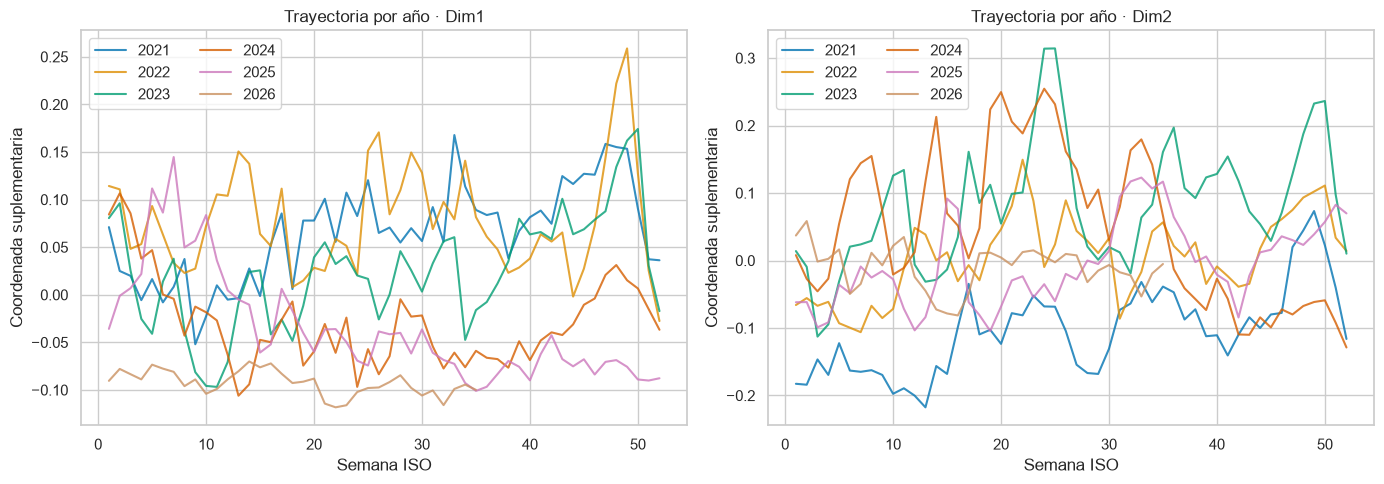

**Lectura temporal.** La curva conjunta indica cómo cambia el perfil promedio a lo largo del calendario. Las curvas por año permiten comprobar si esa forma se repite o si la produce un año particular. Una curva suave en el promedio no basta para afirmar estacionalidad: puede resultar de cobertura desigual o de cambios del catálogo. La siguiente sección contrasta directamente las curvas de participación por producto.

In [11]:
semanas_proyectadas=suplementarias.loc[suplementarias.variable.eq("K_semana")].sort_values("categoria")
mostrar("semanas_proyectadas",semanas_proyectadas,n=12)
fig,axes=plt.subplots(1,2,figsize=(14,5))
sem_num=semanas_proyectadas.categoria.str[1:].astype(int)
axes[0].plot(semanas_proyectadas.Dim1,semanas_proyectadas.Dim2,alpha=.35,color="gray")
pts=axes[0].scatter(semanas_proyectadas.Dim1,semanas_proyectadas.Dim2,c=sem_num,cmap="viridis",s=45)
for (_,r),s in zip(semanas_proyectadas.iterrows(),sem_num):
    if s%4==1 or s==sem_num.max():axes[0].annotate(r.categoria,(r.Dim1,r.Dim2),fontsize=8)
fig.colorbar(pts,ax=axes[0],label="Semana ISO")
axes[0].set(title="Semanas proyectadas en el MCA",xlabel="Dim1",ylabel="Dim2")
axes[1].plot(sem_num,semanas_proyectadas.Dim1,label="Dim1",marker=".")
axes[1].plot(sem_num,semanas_proyectadas.Dim2,label="Dim2",marker=".")
axes[1].set(title="Coordenadas en orden cronológico",xlabel="Semana ISO",ylabel="Coordenada suplementaria")
axes[1].legend()
guardar_figura("07_trayectoria_semanal")

# Comparar el mismo año-semana, sin mezclar años en un único punto.
base_mca["K_anio_semana"]=(base_mca.anio.astype(str)+"-S"+base_mca.semana.astype(str).str.zfill(2)).astype("category")
proyeccion_anual=mp.proyectar_suplementaria(base_mca,mca,"K_anio_semana")
proyeccion_anual["anio"]=proyeccion_anual.categoria.str[:4].astype(int)
proyeccion_anual["semana"]=proyeccion_anual.categoria.str[-2:].astype(int)
mostrar("proyeccion_anio_semana",proyeccion_anual,n=12)
fig,axes=plt.subplots(1,2,figsize=(14,5))
for year,sub in proyeccion_anual.groupby("anio"):
    sub=sub.sort_values("semana")
    for ax,dim in zip(axes,["Dim1","Dim2"]):ax.plot(sub.semana,sub[dim],label=str(year),alpha=.8)
for ax,dim in zip(axes,["Dim1","Dim2"]):
    ax.set(title=f"Trayectoria por año · {dim}",xlabel="Semana ISO",ylabel="Coordenada suplementaria")
    ax.legend(ncol=2)
guardar_figura("08_trayectorias_por_anio")
comentar(
    "**Lectura temporal.** La curva conjunta indica cómo cambia el perfil promedio a lo largo del calendario. "
    "Las curvas por año permiten comprobar si esa forma se repite o si la produce un año particular. "
    "Una curva suave en el promedio no basta para afirmar estacionalidad: puede resultar de cobertura desigual "
    "o de cambios del catálogo. La siguiente sección contrasta directamente las curvas de participación por producto."
)

### 5.1. ¿Se repite la composición semanal de productos?

Se calcula la proporción de tallos de cada producto dentro de cada año-semana. Esto separa **composición** de **volumen total**. Se usa el tramo contiguo más largo de semanas comunes a todos los años seleccionados; no se compara un año completo con 2026 parcial.

Para cada producto se calcula la correlación de sus curvas entre cada par de años y se promedia. Se excluyen pares con curvas constantes. Una correlación positiva indica movimientos semanales concordantes; no demuestra igualdad de volúmenes ni permite pronosticar por sí sola.

Como comprobación exploratoria se desplaza circularmente cada curva anual 199 veces, manteniendo su forma y cambiando su alineación con el calendario. Se compara la concordancia observada con esas alineaciones y se corrige por productos con FDR de Benjamini–Hochberg. Esta referencia supone intercambiabilidad de la fase temporal: no controla cambios de catálogo, cobertura incompleta dentro de una semana ni decisiones comerciales. El resultado se limita al tramo común, y **no prueba un ciclo anual completo**.

,producto,anios,anios_con_variacion,pares_evaluados,semanas_comunes,semana_inicial,semana_final,correlacion_media,p_desplazamiento,q_FDR
0,VERONICA,6,6,15,29,7,35,0.215,0.030,0.180
1,RAFFINE,6,6,15,29,7,35,0.209,0.010,0.120
2,VERONICA SPRAY,6,3,3,29,7,35,0.193,0.330,0.591
3,SOLOMIO,6,6,15,29,7,35,0.118,0.160,0.420
4,STAR,6,6,15,29,7,35,0.092,0.175,0.420
5,AMAZON,6,5,10,29,7,35,0.091,0.140,0.420
6,MINICARNATION,6,6,15,29,7,35,0.034,0.345,0.591
7,CARNATION,6,6,15,29,7,35,-0.011,0.450,0.675
8,BARBATUS,6,6,15,29,7,35,-0.026,0.555,0.740
9,GREEN BALL,6,6,15,29,7,35,-0.048,0.710,0.852


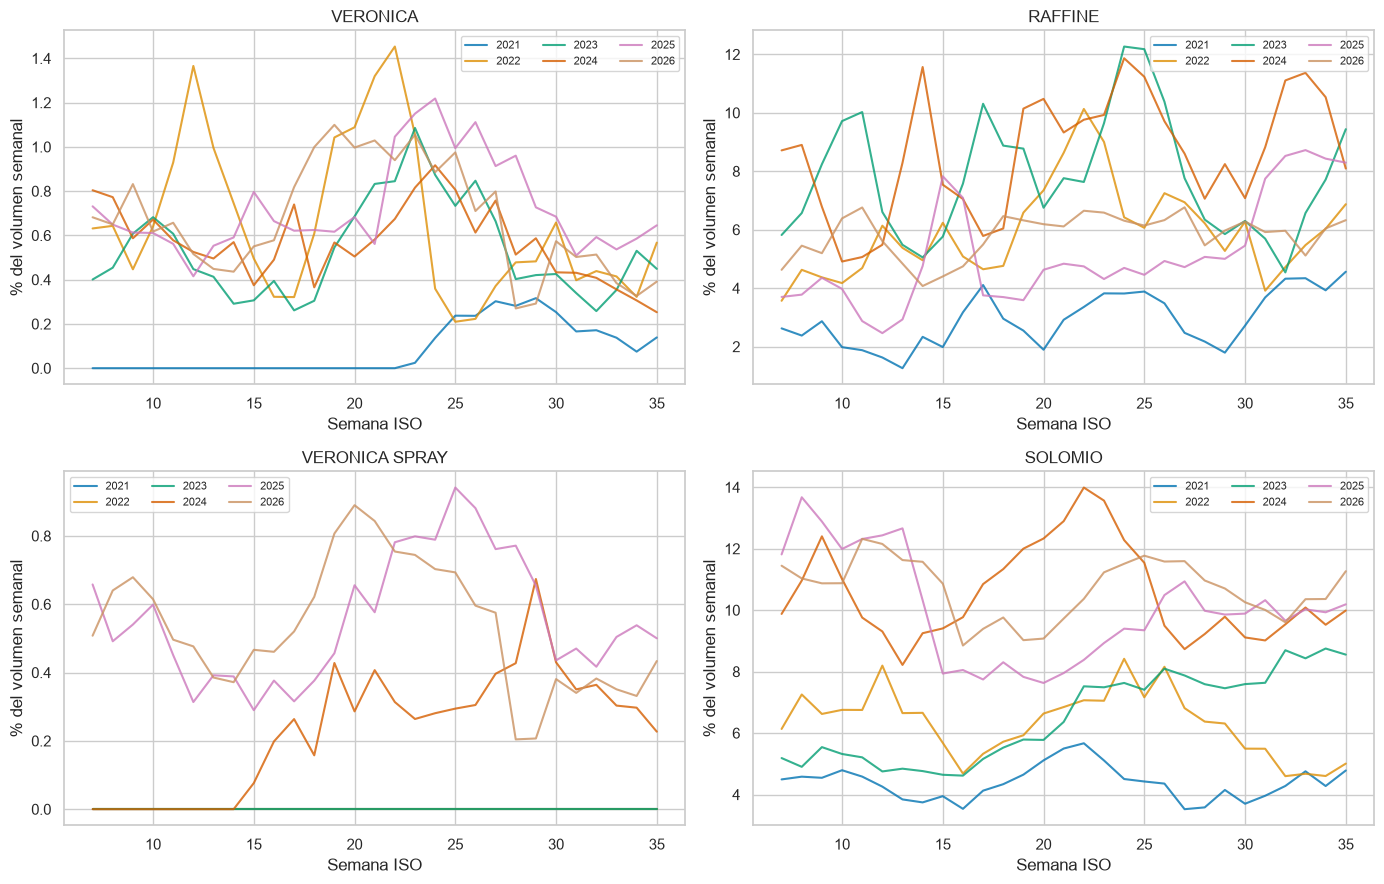

**Recurrencia observada.** Se compararon **29 semanas comunes**, de la **7 a la 35**. La mayor concordancia corresponde a **VERONICA**, con correlación media **0.215** y **q FDR = 0.180**. **0 productos** tienen correlación positiva y q ≤ 0,05 frente a los desplazamientos. Los restantes no muestran esa evidencia bajo este contraste; no equivale a demostrar ausencia de estacionalidad. Antes de usar estos patrones para planear, deben comprobarse en años reservados y con cobertura comparable.

In [12]:
recurrencia, participacion_semanal, semanas_comunes = mp.recurrencia_semanal(base_mca,199,SEMILLA)
mostrar("recurrencia_productos",recurrencia,n=30)
if not recurrencia.empty:
    top_productos=recurrencia.head(4).producto.tolist()
    fig,axes=plt.subplots(2,2,figsize=(14,9),squeeze=False)
    for ax,producto in zip(axes.flat,top_productos):
        for year in sorted(base_mca.anio.unique()):
            serie=participacion_semanal.loc[year,producto].reindex(semanas_comunes)
            ax.plot(serie.index,100*serie,label=str(year),alpha=.8)
        ax.set(title=producto,xlabel="Semana ISO",ylabel="% del volumen semanal")
        ax.legend(ncol=3,fontsize=8)
    for ax in list(axes.flat)[len(top_productos):]:ax.set_visible(False)
    guardar_figura("09_recurrencia_productos")
    primera=recurrencia.iloc[0]
    evidencia=recurrencia.loc[(recurrencia.correlacion_media>0)&(recurrencia.q_FDR<=.05)]
    comentar(
        f"**Recurrencia observada.** Se compararon **{len(semanas_comunes)} semanas comunes**, "
        f"de la **{min(semanas_comunes)} a la {max(semanas_comunes)}**. "
        f"La mayor concordancia corresponde a **{primera.producto}**, con correlación media "
        f"**{primera.correlacion_media:.3f}** y **q FDR = {primera.q_FDR:.3f}**. "
        f"**{len(evidencia)} productos** tienen correlación positiva y q ≤ 0,05 frente a los desplazamientos. "
        "Los restantes no muestran esa evidencia bajo este contraste; no equivale a demostrar ausencia de estacionalidad. "
        "Antes de usar estos patrones para planear, deben comprobarse en años reservados y con cobertura comparable."
    )
else:
    comentar("**Recurrencia no estimable:** no hay suficientes años, semanas comunes contiguas o curvas variables. No se fuerza una conclusión temporal.")

### 5.2. ¿Se repite la forma del volumen semanal?

Aquí se repite el contraste con **tallos por producto y semana**, sin dividir entre el total de la finca. Para graficar, cada curva se expresa como índice: `100 × tallos de la semana / promedio de ese producto-año en las semanas comunes`. Un índice 120 significa 20 % por encima de ese promedio.

La correlación mide semejanza de la forma temporal aunque la escala de producción cambie entre años. Un producto sin volumen en todo el tramo no tiene índice definido y no aporta un par válido. También se muestra el volumen total de la finca en orden semanal, para distinguir un cambio general de producción de uno específico de producto. Los contrastes FDR de volumen forman una familia exploratoria distinta de los de composición.

,producto,anios,anios_con_variacion,pares_evaluados,semanas_comunes,semana_inicial,semana_final,correlacion_media,p_desplazamiento,q_FDR
0,CARNATION,6,6,15,29,7,35,0.566,0.005,0.030
1,MINICARNATION,6,6,15,29,7,35,0.561,0.005,0.030
2,GREEN BALL,6,6,15,29,7,35,0.170,0.060,0.130
3,AMAZON,6,5,10,29,7,35,0.170,0.065,0.130
4,RAFFINE,6,6,15,29,7,35,0.166,0.035,0.105
5,SOLOMIO,6,6,15,29,7,35,0.162,0.030,0.105
6,VERONICA SPRAY,6,3,3,29,7,35,0.145,0.345,0.414
7,STAR,6,6,15,29,7,35,0.109,0.115,0.197
8,BARBATUS,6,6,15,29,7,35,0.102,0.165,0.247
9,VERONICA,6,6,15,29,7,35,0.058,0.225,0.300


,anio,semana,tallos
0,2021,1,"1,028,360.000"
1,2021,2,"991,135.000"
2,2021,3,"924,981.000"
3,2021,4,"860,469.000"
4,2021,5,"834,908.000"
5,2021,6,"919,187.000"
6,2021,7,"868,388.000"
7,2021,8,"711,716.000"
8,2021,9,"650,197.000"
9,2021,10,"748,833.000"


**Volumen semanal.** La mayor concordancia corresponde a **CARNATION** (correlación media **0.566**; q FDR **0.030**). **2 productos** tienen correlación positiva y q ≤ 0,05. Este resultado se refiere a la forma de los volúmenes en el tramo común. Las discrepancias entre volumen y participación ayudan a distinguir variación propia del producto de cambios del total de la finca; ninguna de las dos pruebas identifica por sí sola su causa.

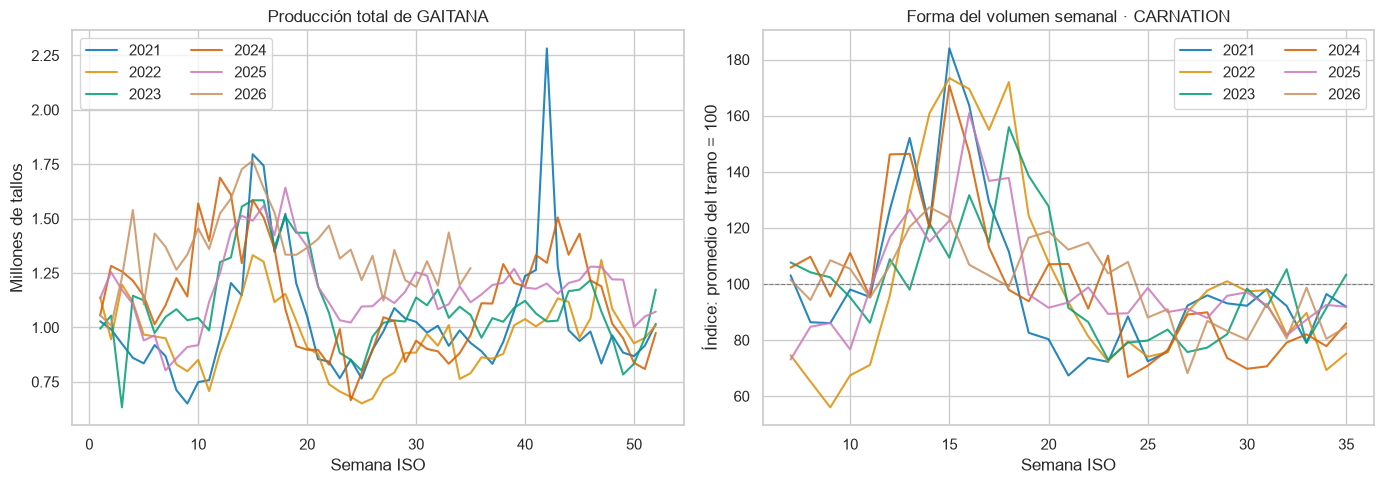

In [13]:
recurrencia_volumen, indice_volumen, semanas_volumen = mp.recurrencia_semanal(
    base_mca,199,SEMILLA,modo="volumen"
)
mostrar("recurrencia_volumen",recurrencia_volumen,n=30)
semanal_total=base_mca.groupby(["anio","semana"],observed=True).tallos.sum().reset_index()
mostrar("volumen_semanal_total",semanal_total,n=12)
fig,axes=plt.subplots(1,2,figsize=(14,5))
for year,sub in semanal_total.groupby("anio"):
    sub=sub.sort_values("semana")
    axes[0].plot(sub.semana,sub.tallos/1e6,label=str(year),alpha=.85)
axes[0].set(title="Producción total de GAITANA",xlabel="Semana ISO",ylabel="Millones de tallos")
axes[0].legend(ncol=2)
if not recurrencia_volumen.empty:
    producto=recurrencia_volumen.iloc[0].producto
    for year in sorted(base_mca.anio.unique()):
        serie=indice_volumen.loc[year,producto].reindex(semanas_volumen)
        axes[1].plot(serie.index,100*serie,label=str(year),alpha=.85)
    axes[1].axhline(100,color="gray",ls="--",lw=.8)
    axes[1].set(title=f"Forma del volumen semanal · {producto}",xlabel="Semana ISO",ylabel="Índice: promedio del tramo = 100")
    axes[1].legend(ncol=2)
    mejor_volumen=recurrencia_volumen.iloc[0]
    significativos_volumen=recurrencia_volumen.loc[(recurrencia_volumen.correlacion_media>0)&(recurrencia_volumen.q_FDR<=.05)]
    comentar(
        f"**Volumen semanal.** La mayor concordancia corresponde a **{producto}** "
        f"(correlación media **{mejor_volumen.correlacion_media:.3f}**; q FDR **{mejor_volumen.q_FDR:.3f}**). "
        f"**{len(significativos_volumen)} productos** tienen correlación positiva y q ≤ 0,05. "
        "Este resultado se refiere a la forma de los volúmenes en el tramo común. "
        "Las discrepancias entre volumen y participación ayudan a distinguir variación propia del producto "
        "de cambios del total de la finca; ninguna de las dos pruebas identifica por sí sola su causa."
    )
else:
    axes[1].set_visible(False)
    comentar("No hay suficientes curvas para evaluar recurrencia de volumen.")
guardar_figura("09b_recurrencia_volumen")

## 6. MCA del grado comercial y análisis de sensibilidad

El segundo MCA añade `grado` como activo únicamente donde está informado. Antes del ajuste se presenta qué porcentaje de producción representa esta subbase por año. No se asume que `GRANEL`, cintas o `NACIONAL` formen una escala universal de calidad: los nombres describen clasificaciones registradas.

Se revisa la relación producto–grado para detectar categorías casi deterministas. Una coincidencia fuerte puede describir la política de clasificación de un producto; no demuestra un defecto de calidad.

,anio,tallos_totales,tallos_grado_conocido,cobertura_grado_pct
0,2021,"53,374,645.000",<NA>,0.000
1,2022,"48,704,873.000","15,478,750.000",31.781
2,2023,"57,341,913.000","57,341,876.000",100.000
3,2024,"58,544,513.000","58,544,513.000",100.000
4,2025,"61,349,519.000","61,349,519.000",100.000
5,2026,"47,348,868.000","47,348,868.000",100.000


,variable,categoria,masa_pct,Dim1,contrib_Dim1_pct,cos2_Dim1,Dim2,contrib_Dim2_pct,cos2_Dim2,Dim3,contrib_Dim3_pct,cos2_Dim3,Dim4,contrib_Dim4_pct,cos2_Dim4,Dim5,contrib_Dim5_pct,cos2_Dim5,Dim6,contrib_Dim6_pct,cos2_Dim6,Dim7,contrib_Dim7_pct,cos2_Dim7,Dim8,contrib_Dim8_pct,cos2_Dim8,cos2_plano
41,K_grado,NACIONAL,0.058,23.742,49.593,0.974,0.595,0.038,0.001,0.425,0.020,0.000,0.023,0.000,0.000,-0.506,0.032,0.000,0.093,0.001,0.000,0.297,0.012,0.000,-0.075,0.001,0.000,0.975
9,K_producto,STATICE,0.052,24.837,49.549,0.973,0.586,0.034,0.001,0.480,0.023,0.000,-0.173,0.003,0.000,-0.869,0.087,0.001,-0.111,0.001,0.000,0.221,0.006,0.000,0.022,0.000,0.000,0.974
25,K_color,LIGHT PINK,3.665,0.138,0.107,0.002,0.098,0.066,0.001,-0.382,1.038,0.018,-0.466,1.658,0.027,0.362,1.055,0.016,-0.570,2.663,0.040,-0.009,0.001,0.000,-0.288,0.739,0.010,0.004
24,K_color,LAVENDER,1.695,0.203,0.106,0.002,-0.336,0.359,0.006,-0.138,0.063,0.001,-0.162,0.093,0.001,-0.082,0.025,0.000,-0.421,0.673,0.009,-0.308,0.380,0.005,-0.496,1.019,0.013,0.008
40,K_grado,GRANEL,28.495,-0.044,0.085,0.012,0.138,1.016,0.112,0.007,0.003,0.000,0.062,0.231,0.023,-0.015,0.013,0.001,0.077,0.378,0.035,0.039,0.105,0.009,0.085,0.506,0.043,0.123
23,K_color,HOT PINK,3.006,0.106,0.052,0.001,-0.489,1.352,0.024,-0.057,0.019,0.000,-0.434,1.182,0.019,-0.016,0.002,0.000,0.853,4.899,0.072,0.227,0.367,0.005,0.063,0.030,0.000,0.025
11,K_producto,VERONICA,0.190,0.412,0.049,0.001,0.350,0.044,0.001,-0.418,0.064,0.001,2.682,2.843,0.041,4.151,7.178,0.099,-0.031,0.000,0.000,0.768,0.265,0.003,-0.344,0.055,0.001,0.002
29,K_color,PURPLE,1.351,0.153,0.048,0.001,-0.361,0.330,0.005,-0.052,0.007,0.000,1.254,4.425,0.066,1.241,4.570,0.065,-0.094,0.027,0.000,-2.251,16.220,0.214,2.563,21.625,0.277,0.006
22,K_color,GREEN,1.730,-0.134,0.048,0.001,1.306,5.552,0.093,3.427,39.393,0.643,-0.457,0.754,0.011,0.268,0.272,0.004,-0.093,0.034,0.000,-0.244,0.245,0.003,-0.211,0.187,0.002,0.094
2,K_producto,CARNATION,6.318,-0.064,0.040,0.001,0.249,0.734,0.014,0.047,0.027,0.001,1.281,21.601,0.384,-0.949,12.510,0.211,0.129,0.235,0.004,-0.189,0.537,0.008,-0.241,0.898,0.014,0.015


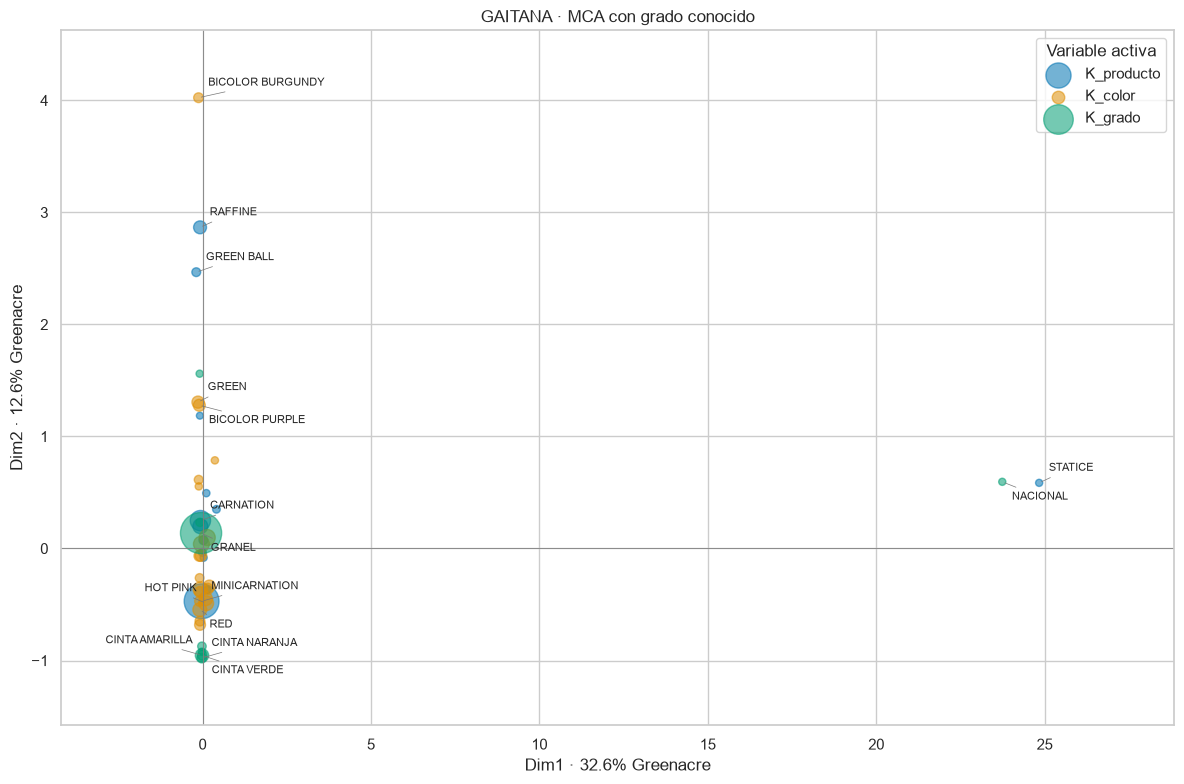

K_grado,K_producto,CINTA AMARILLA,CINTA BLANCA,CINTA NARANJA,CINTA NEGRA,CINTA VERDE,FCY,GRANEL,NACIONAL,OTROS
0,AMAZON,0.000,0.000,0.000,0.000,0.000,0.000,99.810,0.112,0.078
1,BARBATUS,0.000,0.000,0.000,0.000,0.000,0.000,98.553,0.000,1.447
2,CARNATION,0.210,1.531,1.750,4.203,1.448,0.119,90.540,0.000,0.199
3,GREEN BALL,0.000,0.000,0.000,0.000,0.000,0.000,98.230,0.000,1.770
4,MINICARNATION,3.685,1.683,3.496,0.321,10.105,0.325,80.289,0.002,0.094
5,OTROS,0.000,0.000,0.000,0.000,0.000,0.000,100.000,0.000,0.000
6,RAFFINE,0.177,0.000,0.000,0.000,0.170,0.007,99.264,0.008,0.374
7,SOLOMIO,0.637,0.000,0.078,0.598,3.845,0.093,94.301,0.008,0.440
8,STAR,0.020,0.000,0.000,0.000,0.367,0.013,98.772,0.268,0.560
9,STATICE,0.000,0.000,0.000,0.000,0.000,0.000,0.000,99.968,0.032


,K_producto,grado_dominante,porcentaje_dominante,tallos
0,OTROS,GRANEL,100.000,"75,194.000"
1,STATICE,NACIONAL,99.968,"378,083.000"
2,TRACHELIUM,GRANEL,99.924,"395,732.000"
3,VERONICA SPRAY,GRANEL,99.863,"699,873.000"
4,AMAZON,GRANEL,99.810,"537,657.000"
5,RAFFINE,GRANEL,99.264,"14,851,059.000"
6,STAR,GRANEL,98.772,"3,675,164.000"
7,BARBATUS,GRANEL,98.553,"1,635,881.000"
8,VERONICA,GRANEL,98.514,"1,365,829.000"
9,GREEN BALL,GRANEL,98.230,"3,698,433.000"


**Grado comercial.** Esta subbase representa **73.5 %** de los tallos del análisis principal. El grado aporta **49.7 % a Dim1** y **8.8 % a Dim2** de este segundo ajuste. La tabla producto–grado permite comprobar si el mapa está destacando una clasificación casi exclusiva de un producto. No se atribuye esa asociación al manejo agronómico ni se supone un destino comercial que el archivo no documenta.

In [14]:
base_grado=base_mca.loc[base_mca["K_grado_sin_agrupar"].ne("SIN_DATO")].copy()
cobertura_grado=base_mca.groupby("anio").tallos.sum().to_frame("tallos_totales")
cobertura_grado["tallos_grado_conocido"]=base_grado.groupby("anio").tallos.sum()
cobertura_grado["cobertura_grado_pct"]=100*cobertura_grado.tallos_grado_conocido.fillna(0)/cobertura_grado.tallos_totales
mostrar("cobertura_grado",cobertura_grado.reset_index())
mca_grado=mp.ajustar_mca(base_grado,ACTIVAS+["K_grado"])
categorias_grado=mp.resultados_categorias(mca_grado)
mostrar("coordenadas_mca_grado",categorias_grado.sort_values("contrib_Dim1_pct",ascending=False))
mapa_mca(mca_grado,"GAITANA · MCA con grado conocido", "10_mca_grado")

tabla_pg=mp.tabla_pesos(base_grado,"K_producto","K_grado")
perfiles_grado=100*tabla_pg.div(tabla_pg.sum(axis=1),axis=0)
mostrar("grado_por_producto",perfiles_grado.reset_index())
dominancia=pd.DataFrame({"grado_dominante":perfiles_grado.idxmax(axis=1),
                         "porcentaje_dominante":perfiles_grado.max(axis=1),"tallos":tabla_pg.sum(axis=1)})
mostrar("dominancia_grado",dominancia.sort_values("porcentaje_dominante",ascending=False).reset_index())
aporte_grado=categorias_grado.loc[categorias_grado.variable.eq("K_grado"),["contrib_Dim1_pct","contrib_Dim2_pct"]].sum()
comentar(
    f"**Grado comercial.** Esta subbase representa **{100*base_grado.tallos.sum()/base_mca.tallos.sum():.1f} %** "
    f"de los tallos del análisis principal. El grado aporta **{aporte_grado.iloc[0]:.1f} % a Dim1** y "
    f"**{aporte_grado.iloc[1]:.1f} % a Dim2** de este segundo ajuste. "
    "La tabla producto–grado permite comprobar si el mapa está destacando una clasificación casi exclusiva "
    "de un producto. No se atribuye esa asociación al manejo agronómico ni se supone un destino comercial "
    "que el archivo no documenta."
)

### 6.1. ¿El resultado depende de una decisión del análisis?

Se comparan: semana como activa, mismo peso por registro, producto–grado–semana como activas y MCA comercial sin STATICE. El principal conserva todos los productos; retirar STATICE es únicamente una prueba de sensibilidad. Los ejes de ajustes distintos no son intercambiables: se comparan sus variables contribuyentes y la cobertura, no el signo o la distancia de un punto entre mapas.

In [15]:
sensibilidad=[]
def registrar_modelo(nombre,df,activas,peso="tallos"):
    modelo=mp.ajustar_mca(df,activas,peso=peso)
    cat=mp.resultados_categorias(modelo)
    contrib=cat.groupby("variable")[["contrib_Dim1_pct","contrib_Dim2_pct"]].sum()
    sensibilidad.append({"modelo":nombre,"registros":len(df),"tallos":df.tallos.sum(),
        "variables":", ".join(modelo["activas"]),"plano_crudo_pct":sum(modelo["inercia_cruda_pct"][:2]),
        "plano_greenacre_pct":sum(modelo["inercia_greenacre_pct"][:2]),
        "mayor_aporte_Dim1":contrib.contrib_Dim1_pct.idxmax(),
        "aporte_semana_Dim1_pct":contrib.loc["K_semana","contrib_Dim1_pct"] if "K_semana" in contrib.index else np.nan,
        "aporte_grado_Dim1_pct":contrib.loc["K_grado","contrib_Dim1_pct"] if "K_grado" in contrib.index else np.nan})
    return modelo

registrar_modelo("Principal",base_mca,ACTIVAS)
mca_semana=registrar_modelo("Semana activa",base_mca,ACTIVAS+["K_semana"])
base_mca["peso_registro"]=1
registrar_modelo("Peso igual por registro",base_mca,ACTIVAS,"peso_registro")
registrar_modelo("Producto, grado y semana",base_grado,["K_producto","K_grado","K_semana"])
registrar_modelo("Grado activo",base_grado,ACTIVAS+["K_grado"])
sin_statice=base_grado.loc[base_grado.K_producto_sin_agrupar.ne("STATICE")]
if len(sin_statice) and len(sin_statice)<len(base_grado):
    registrar_modelo("Grado activo sin STATICE",sin_statice,ACTIVAS+["K_grado"])
sensibilidad=pd.DataFrame(sensibilidad)
mostrar("sensibilidad",sensibilidad)
mostrar("semana_activa_coordenadas",mp.resultados_categorias(mca_semana))
sem_act=sensibilidad.loc[sensibilidad.modelo.eq("Semana activa")].iloc[0]
comentar(
    f"**Semana activa.** Aporta **{sem_act.aporte_semana_Dim1_pct:.1f} % a Dim1** y el plano 1–2 "
    f"recoge **{sem_act.plano_crudo_pct:.1f} % de inercia cruda** en ese ajuste. "
    "Esto mide cuánto participa en los ejes cuando se le permite construirlos, no el porcentaje de "
    "producción explicado por el calendario. La comparación por registros cambia la pregunta: "
    "describe el registro típico, mientras el ajuste ponderado describe la distribución de los tallos."
)

,modelo,registros,tallos,variables,plano_crudo_pct,plano_greenacre_pct,mayor_aporte_Dim1,aporte_semana_Dim1_pct,aporte_grado_Dim1_pct
0,Principal,4638217,"326,664,331.000","K_producto, K_color",9.710,57.502,K_color,NaN,NaN
1,Semana activa,4638217,"326,664,331.000","K_producto, K_color, K_semana",3.751,42.705,K_color,0.367,NaN
2,Peso igual por registro,4638217,"326,664,331.000","K_producto, K_color",9.785,55.843,K_color,NaN,NaN
3,"Producto, grado y semana",3458229,"240,063,526.000","K_producto, K_grado, K_semana",4.705,61.697,K_producto,0.071,49.964
4,Grado activo,3458229,"240,063,526.000","K_producto, K_color, K_grado",8.891,45.194,K_producto,NaN,49.684
5,Grado activo sin STATICE,3450760,"239,685,443.000","K_producto, K_color, K_grado",8.061,40.429,K_producto,NaN,8.810


,variable,categoria,masa_pct,Dim1,contrib_Dim1_pct,cos2_Dim1,Dim2,contrib_Dim2_pct,cos2_Dim2,Dim3,contrib_Dim3_pct,cos2_Dim3,Dim4,contrib_Dim4_pct,cos2_Dim4,Dim5,contrib_Dim5_pct,cos2_Dim5,Dim6,contrib_Dim6_pct,cos2_Dim6,Dim7,contrib_Dim7_pct,cos2_Dim7,Dim8,contrib_Dim8_pct,cos2_Dim8,cos2_plano
0,K_producto,AMAZON,0.066,-0.227,0.007,0.000,-0.941,0.114,0.002,3.523,1.763,0.025,-0.688,0.072,0.001,0.676,0.071,0.001,11.818,22.210,0.279,10.096,16.839,0.203,-1.210,0.261,0.003,0.002
1,K_producto,BARBATUS,0.223,-0.385,0.063,0.001,0.023,0.000,0.000,0.004,0.000,0.000,-0.079,0.003,0.000,-0.582,0.177,0.002,-0.436,0.101,0.001,0.221,0.027,0.000,6.269,23.554,0.265,0.001
2,K_producto,CARNATION,6.158,-0.022,0.006,0.000,-0.026,0.008,0.000,0.485,3.096,0.053,-0.884,11.002,0.177,1.319,25.118,0.394,-0.279,1.149,0.018,-0.047,0.033,0.000,0.029,0.014,0.000,0.000
3,K_producto,GREEN BALL,0.595,6.210,43.976,0.701,1.944,4.365,0.069,0.105,0.014,0.000,0.407,0.225,0.003,-0.053,0.004,0.000,0.315,0.141,0.002,-0.165,0.041,0.000,0.029,0.001,0.000,0.770
4,K_producto,MINICARNATION,20.961,-0.045,0.081,0.003,-0.344,4.824,0.201,-0.181,1.475,0.056,0.082,0.320,0.011,-0.333,5.439,0.188,0.222,2.470,0.083,-0.252,3.302,0.107,-0.043,0.102,0.003,0.204
5,K_producto,OTROS,0.018,0.993,0.034,0.001,0.330,0.004,0.000,0.465,0.008,0.000,1.378,0.078,0.001,0.645,0.017,0.000,2.071,0.184,0.002,1.283,0.073,0.001,2.056,0.203,0.002,0.001
6,K_producto,RAFFINE,1.868,-1.219,5.319,0.088,3.337,40.336,0.661,-0.185,0.136,0.002,0.055,0.013,0.000,-0.277,0.337,0.005,0.358,0.572,0.008,-0.191,0.170,0.002,-0.092,0.043,0.001,0.749
7,K_producto,SOLOMIO,2.689,0.034,0.006,0.000,0.052,0.014,0.000,-0.233,0.312,0.005,0.105,0.068,0.001,-0.635,2.541,0.035,-1.680,18.189,0.248,1.880,23.653,0.310,-0.332,0.797,0.010,0.000
8,K_producto,STAR,0.433,-0.451,0.168,0.003,-0.168,0.024,0.000,-1.426,1.881,0.027,5.731,32.460,0.432,3.744,14.215,0.184,0.017,0.000,0.000,0.470,0.237,0.003,0.209,0.051,0.001,0.003
9,K_producto,STATICE,0.039,-0.340,0.009,0.000,-0.336,0.008,0.000,0.036,0.000,0.000,0.096,0.001,0.000,-0.856,0.066,0.001,1.332,0.164,0.002,0.088,0.001,0.000,0.711,0.052,0.001,0.000


**Semana activa.** Aporta **0.4 % a Dim1** y el plano 1–2 recoge **3.8 % de inercia cruda** en ese ajuste. Esto mide cuánto participa en los ejes cuando se le permite construirlos, no el porcentaje de producción explicado por el calendario. La comparación por registros cambia la pregunta: describe el registro típico, mientras el ajuste ponderado describe la distribución de los tallos.

### 6.2. MCA con imputación y todos los registros: sensibilidad

Se incorpora `grado_analisis` con sus predicciones identificadas y su categoría `SIN_REFERENCIA`. Este ajuste incluye todos los registros de la base MCA, también los que no tienen grado observado. Se compara con los modelos anteriores; la subbase de grado observado permanece como referencia para describir porcentajes comerciales sin mezclar predicciones.

`SIN_REFERENCIA` puede construir un eje por ausencia histórica de información. Se reporta su contribución y se evita interpretarla como un grado real. **Imputar por producto y variedad también puede reforzar artificialmente su asociación con el grado.** El ajuste se presenta como sensibilidad, no como evidencia independiente ni como reconstrucción confirmada de 2021.

,variable,categoria,masa_pct,Dim1,contrib_Dim1_pct,cos2_Dim1,Dim2,contrib_Dim2_pct,cos2_Dim2,Dim3,contrib_Dim3_pct,cos2_Dim3,Dim4,contrib_Dim4_pct,cos2_Dim4,Dim5,contrib_Dim5_pct,cos2_Dim5,Dim6,contrib_Dim6_pct,cos2_Dim6,Dim7,contrib_Dim7_pct,cos2_Dim7,Dim8,contrib_Dim8_pct,cos2_Dim8,cos2_plano
52,K_grado_imputado,NACIONAL,0.042,27.678,49.706,0.975,0.323,0.008,0.000,0.639,0.033,0.001,-0.149,0.002,0.000,0.486,0.022,0.000,0.114,0.001,0.000,0.336,0.011,0.000,-0.049,0.000,0.000,0.975
9,K_producto,STATICE,0.039,28.988,49.669,0.974,0.262,0.005,0.000,0.676,0.033,0.001,-0.512,0.021,0.000,0.841,0.060,0.001,-0.084,0.001,0.000,0.266,0.007,0.000,0.080,0.001,0.000,0.974
24,K_color,LAVENDER,1.704,0.172,0.078,0.002,-0.276,0.238,0.004,-0.264,0.223,0.004,-0.159,0.091,0.001,0.059,0.013,0.000,-0.389,0.588,0.008,-0.267,0.291,0.004,-0.504,1.062,0.014,0.006
25,K_color,LIGHT PINK,3.815,0.109,0.070,0.002,0.178,0.223,0.004,-0.226,0.366,0.007,-0.418,1.411,0.023,-0.492,2.051,0.031,-0.527,2.413,0.036,-0.028,0.007,0.000,-0.289,0.784,0.011,0.006
48,K_grado_imputado,GRANEL,21.323,-0.040,0.052,0.003,0.335,4.417,0.200,0.039,0.061,0.003,0.107,0.511,0.020,0.049,0.115,0.004,0.131,0.840,0.031,0.027,0.037,0.001,0.148,1.141,0.039,0.203
11,K_producto,VERONICA,0.172,0.399,0.042,0.001,0.807,0.206,0.003,-0.262,0.022,0.000,4.792,8.328,0.119,-4.240,6.843,0.093,-0.144,0.008,0.000,1.133,0.527,0.007,-0.987,0.410,0.005,0.004
29,K_color,PURPLE,1.290,0.138,0.038,0.001,-0.159,0.060,0.001,-0.266,0.172,0.003,1.387,5.246,0.077,-0.502,0.720,0.010,-0.202,0.120,0.002,-2.672,22.025,0.288,2.414,18.448,0.235,0.002
22,K_color,GREEN,1.829,-0.114,0.036,0.001,-0.515,0.893,0.015,3.544,43.285,0.729,-0.071,0.019,0.000,-0.165,0.111,0.002,0.005,0.000,0.000,-0.082,0.030,0.000,-0.041,0.008,0.000,0.016
23,K_color,HOT PINK,3.362,0.074,0.028,0.001,-0.406,1.020,0.018,-0.257,0.417,0.007,-0.353,0.886,0.014,-0.120,0.108,0.002,0.780,4.669,0.068,0.313,0.788,0.011,0.123,0.126,0.002,0.019
2,K_producto,CARNATION,6.158,-0.052,0.025,0.001,0.216,0.531,0.011,0.044,0.022,0.000,0.965,12.110,0.211,1.277,22.277,0.370,0.003,0.000,0.000,-0.074,0.081,0.001,-0.299,1.346,0.020,0.011


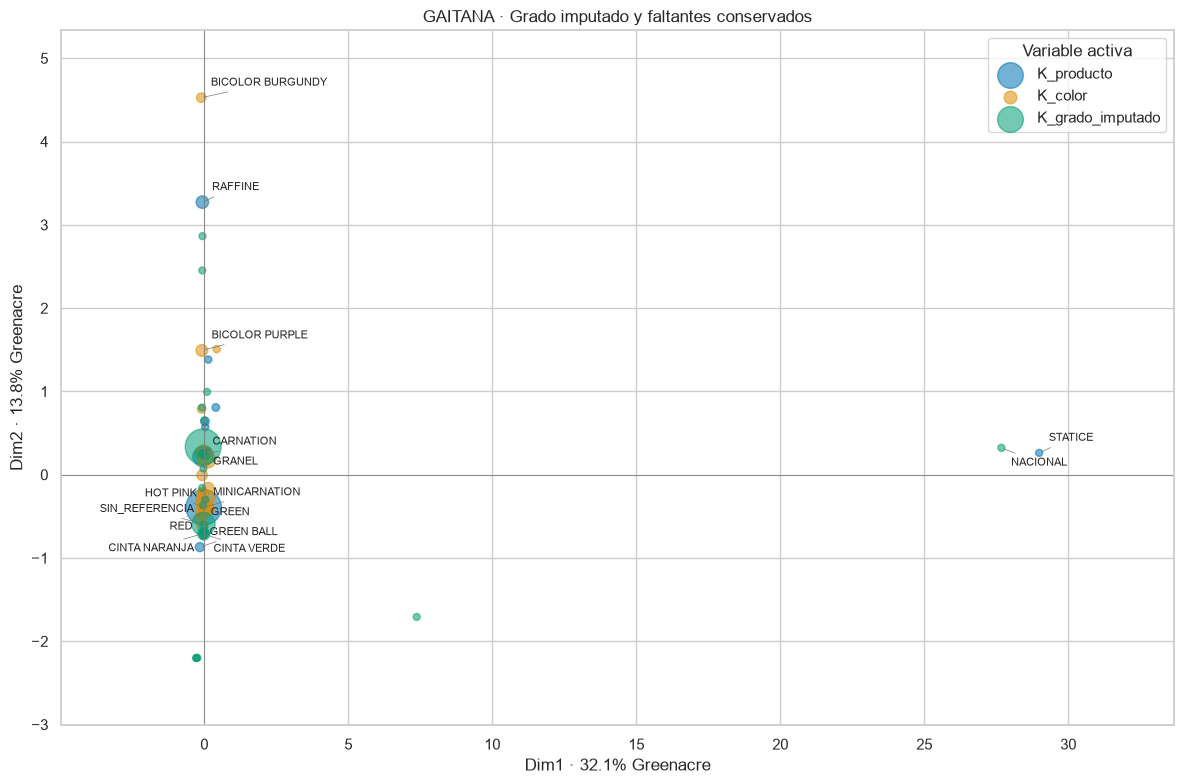

,variable,categoria,tallos,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8
0,K_corte_imputado,CORTE 1,"70,424,802.000",0.069,0.261,-0.009,0.110,-0.065,0.154,0.129,0.216
1,K_corte_imputado,CORTE 2,"123,221,530.000",-0.004,-0.019,-0.067,0.024,0.053,-0.045,-0.028,-0.040
2,K_corte_imputado,CORTE 3,"614,782.000",-0.052,0.710,-0.154,-0.126,0.212,0.870,-0.185,-0.204
3,K_corte_imputado,CORTE 4,"10,490.000",-0.065,0.078,-0.341,-0.091,-0.083,-0.350,0.964,0.435
4,K_corte_imputado,CORTE 5,70.000,-0.096,0.823,0.125,2.706,4.145,0.342,-0.169,-0.978
5,K_corte_imputado,SIN_REFERENCIA,"132,392,657.000",-0.033,-0.125,0.068,-0.080,-0.015,-0.044,-0.041,-0.077


**MCA sin eliminar faltantes.** Este ajuste incluye **4,638,217 registros**, el **100 % de los 326,664,331 tallos** de la base MCA. SIN_REFERENCIA aporta **0.0 % a Dim1**. Los porcentajes comerciales de la siguiente sección se calculan únicamente con grados observados; las filas sin grado siguen disponibles en la base general y en este ajuste.

In [16]:
base_mca["K_grado_imputado"]=base_mca.grado_analisis.replace({"NAC":"NACIONAL", "NA":"NACIONAL"})
base_mca["K_corte_imputado"]=base_mca.tipo_corte_analisis
mca_imputado=mp.ajustar_mca(base_mca, ACTIVAS+["K_grado_imputado"])
cat_imputado=mp.resultados_categorias(mca_imputado)
mostrar("mca_grado_imputado", cat_imputado.sort_values("contrib_Dim1_pct", ascending=False))
mapa_mca(mca_imputado,"GAITANA · Grado imputado y faltantes conservados", "10b_mca_grado_imputado")
mostrar("corte_imputado_suplementario", mp.proyectar_suplementaria(base_mca,mca_imputado,"K_corte_imputado"))
sin_ref=cat_imputado.loc[cat_imputado.variable.eq("K_grado_imputado") & cat_imputado.categoria.eq("SIN_REFERENCIA")]
aporte_sin_ref=float(sin_ref.contrib_Dim1_pct.sum())
comentar(
    f"**MCA sin eliminar faltantes.** Este ajuste incluye **{len(base_mca):,} registros**, "
    f"el **100 % de los {base_mca.tallos.sum():,.0f} tallos** de la base MCA. "
    f"SIN_REFERENCIA aporta **{aporte_sin_ref:.1f} % a Dim1**. "
    "Los porcentajes comerciales de la siguiente sección se calculan únicamente con grados observados; "
    "las filas sin grado siguen disponibles en la base general y en este ajuste."
)

## 7. Producto y grado: detalle por variedad y año

Se aísla la tabla producto–grado y se realiza un análisis de correspondencias simple. Se reporta V de Cramér como tamaño descriptivo de asociación, sin usar p-valores basados en independencia entre tallos.

Después se comparan porcentajes de **no GRANEL** por variedad dentro de cada producto y año. Esta definición es operativa: “no GRANEL” no significa automáticamente peor calidad, ni pérdida, ni menor precio. Separar por producto y año reduce dos mezclas relevantes, pero no controla semana, bloque o política comercial.

K_grado,K_producto,CINTA AMARILLA,CINTA BLANCA,CINTA NARANJA,CINTA NEGRA,CINTA VERDE,FCY,GRANEL,NACIONAL,OTROS
0,AMAZON,0.000,0.000,0.000,0.000,0.000,0.000,"536,637.000",600.000,420.000
1,BARBATUS,0.000,0.000,0.000,0.000,0.000,0.000,"1,612,202.000",0.000,"23,679.000"
2,CARNATION,"95,620.000","696,649.000","796,146.000","1,912,792.000","658,823.000","54,341.000","41,200,244.000",160.000,"90,414.000"
3,GREEN BALL,0.000,0.000,0.000,0.000,0.000,0.000,"3,632,973.000",0.000,"65,460.000"
4,MINICARNATION,"5,356,099.000","2,446,331.000","5,080,859.000","466,511.000","14,686,900.000","472,569.000","116,697,848.000","2,800.000","136,716.000"
5,OTROS,0.000,0.000,0.000,0.000,0.000,0.000,"75,194.000",0.000,0.000
6,RAFFINE,"26,285.000",0.000,0.000,0.000,"25,215.000","1,080.000","14,741,719.000","1,200.000","55,560.000"
7,SOLOMIO,"139,571.000",0.000,"17,115.000","130,951.000","842,010.000","20,364.000","20,650,808.000","1,680.000","96,300.000"
8,STAR,720.000,0.000,0.000,0.000,"13,505.000",480.000,"3,630,039.000","9,840.000","20,580.000"
9,STATICE,0.000,0.000,0.000,0.000,0.000,0.000,0.000,"377,963.000",120.000


K_grado,K_producto,CINTA AMARILLA,CINTA BLANCA,CINTA NARANJA,CINTA NEGRA,CINTA VERDE,FCY,GRANEL,NACIONAL,OTROS
0,AMAZON,0.000,0.000,0.000,0.000,0.000,0.000,99.810,0.112,0.078
1,BARBATUS,0.000,0.000,0.000,0.000,0.000,0.000,98.553,0.000,1.447
2,CARNATION,0.210,1.531,1.750,4.203,1.448,0.119,90.540,0.000,0.199
3,GREEN BALL,0.000,0.000,0.000,0.000,0.000,0.000,98.230,0.000,1.770
4,MINICARNATION,3.685,1.683,3.496,0.321,10.105,0.325,80.289,0.002,0.094
5,OTROS,0.000,0.000,0.000,0.000,0.000,0.000,100.000,0.000,0.000
6,RAFFINE,0.177,0.000,0.000,0.000,0.170,0.007,99.264,0.008,0.374
7,SOLOMIO,0.637,0.000,0.078,0.598,3.845,0.093,94.301,0.008,0.440
8,STAR,0.020,0.000,0.000,0.000,0.367,0.013,98.772,0.268,0.560
9,STATICE,0.000,0.000,0.000,0.000,0.000,0.000,0.000,99.968,0.032


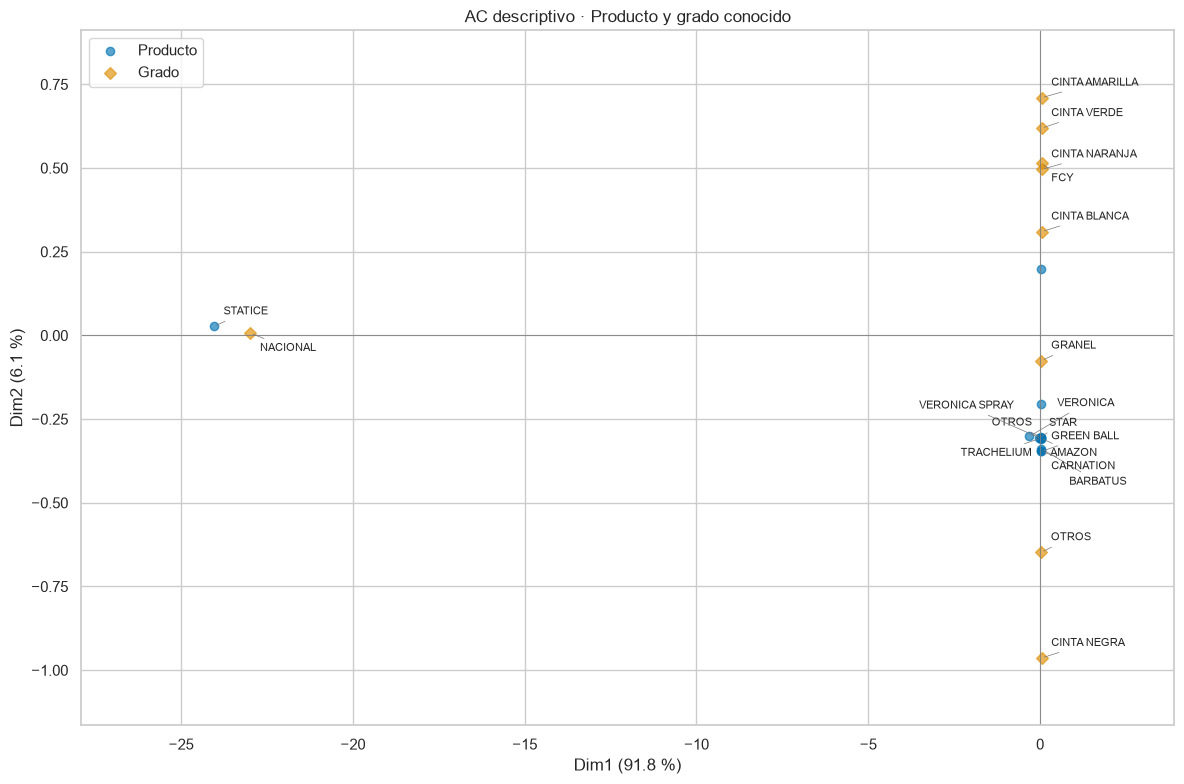

,anio,K_producto,K_variedad,tallos,tallos_no_granel,semanas,no_granel_pct
956,2025,MINICARNATION,UCHUVA,"3,004,276.000","461,074.000",52,15.347
391,2023,MINICARNATION,CAESAR,"2,878,275.000","379,104.000",52,13.171
446,2023,MINICARNATION,UCHUVA,"2,697,280.000","414,266.000",52,15.359
651,2024,MINICARNATION,CAESAR,"2,536,810.000","490,198.000",52,19.323
691,2024,MINICARNATION,UCHUVA,"2,408,792.000","606,011.000",52,25.158
641,2024,MINICARNATION,ACADEMY,"2,401,527.000","794,745.000",52,33.093
673,2024,MINICARNATION,LORENZO,"2,372,163.000","553,453.000",52,23.331
1182,2026,MINICARNATION,UCHUVA,"2,330,056.000","356,899.000",35,15.317
889,2025,MINICARNATION,ACADEMY,"2,240,750.000","575,188.000",52,25.669
899,2025,MINICARNATION,CAESAR,"2,188,688.000","381,891.000",52,17.448


,anio,K_producto,variedades,minimo_pct,maximo_pct,rango_pp
2,2022,MINICARNATION,27,3.962,56.299,52.337
16,2024,MINICARNATION,32,3.134,55.345,52.211
25,2025,MINICARNATION,32,7.310,52.163,44.853
8,2023,MINICARNATION,35,0.317,43.791,43.474
23,2025,CARNATION,42,7.379,39.765,32.386
32,2026,CARNATION,36,2.551,20.552,18.002
10,2023,SOLOMIO,12,0.055,17.627,17.571
34,2026,MINICARNATION,30,8.285,24.381,16.096
14,2024,CARNATION,39,0.000,11.706,11.706
27,2025,SOLOMIO,11,2.093,13.466,11.373


**Asociación producto–grado.** V de Cramér es **0.353** en los tallos con grado conocido. Hay **31 combinaciones año–producto** con al menos dos variedades que cumplen 100.000 tallos y 12 semanas observadas. Sus diferencias se expresan en puntos porcentuales, sin cocientes inestables cuando una variedad tiene 0 %. Aun dentro del mismo producto y año, las semanas efectivamente cosechadas y la política comercial pueden explicar parte de la diferencia. Por tanto, el resultado orienta una revisión operativa; no demuestra un efecto causal de la variedad.

In [17]:
tabla_producto_grado=mp.tabla_pesos(base_grado,"K_producto","K_grado")
ac=mp.ajustar_ac(tabla_producto_grado)
mostrar("producto_grado_tallos",tabla_producto_grado.reset_index())
mostrar("producto_grado_porcentaje",(100*tabla_producto_grado.div(tabla_producto_grado.sum(axis=1),axis=0)).reset_index())
if len(ac["eig"])>=2:
    fig,ax=plt.subplots(figsize=(12,8))
    ax.axhline(0,color="gray",lw=.6);ax.axvline(0,color="gray",lw=.6)
    etiquetas_ac=[]
    for coord,nombres,marker,label in [(ac["coords_filas"],ac["filas"],"o","Producto"),
                                     (ac["coords_columnas"],ac["columnas"],"D","Grado")]:
        ax.scatter(coord[:,0],coord[:,1],marker=marker,alpha=.65,label=label)
        # Rotular los grados y los productos más alejados, sin ocultar puntos.
        indices=range(len(nombres)) if label=="Grado" else np.argsort(np.sum(coord[:,:2]**2,axis=1))[-10:]
        for i in indices:etiquetas_ac.append((coord[i,0],coord[i,1],str(nombres[i])))
    mp.etiquetar_mapa(ax,etiquetas_ac)
    ax.set(title="AC descriptivo · Producto y grado conocido",xlabel=f"Dim1 ({ac['inercia_pct'][0]:.1f} %)",
           ylabel=f"Dim2 ({ac['inercia_pct'][1]:.1f} %)")
    ax.legend();guardar_figura("11_ac_producto_grado")

base_grado["tallos_no_granel"]=base_grado.tallos.where(base_grado.K_grado_sin_agrupar.ne("GRANEL"),0)
variedad_producto=base_grado.groupby(["anio","K_producto","K_variedad"],observed=True).agg(
    tallos=("tallos","sum"),tallos_no_granel=("tallos_no_granel","sum"),
    semanas=("semana","nunique")
).reset_index()
variedad_producto["no_granel_pct"]=100*variedad_producto.tallos_no_granel/variedad_producto.tallos
mostrar("variedad_producto_anio",variedad_producto.sort_values("tallos",ascending=False))
comparables=variedad_producto.loc[(variedad_producto.tallos>=100_000)&(variedad_producto.semanas>=12)]
contrastes=comparables.groupby(["anio","K_producto"],observed=True).agg(
    variedades=("K_variedad","nunique"),minimo_pct=("no_granel_pct","min"),maximo_pct=("no_granel_pct","max")
).reset_index()
contrastes=contrastes.loc[contrastes.variedades>=2].copy()
contrastes["rango_pp"]=contrastes.maximo_pct-contrastes.minimo_pct
mostrar("contrastes_variedad",contrastes.sort_values("rango_pp",ascending=False))
comentar(
    f"**Asociación producto–grado.** V de Cramér es **{ac['V']:.3f}** en los tallos con grado conocido. "
    f"Hay **{len(contrastes)} combinaciones año–producto** con al menos dos variedades que cumplen "
    "100.000 tallos y 12 semanas observadas. Sus diferencias se expresan en puntos porcentuales, "
    "sin cocientes inestables cuando una variedad tiene 0 %. Aun dentro del mismo producto y año, "
    "las semanas efectivamente cosechadas y la política comercial pueden explicar parte de la diferencia. "
    "Por tanto, el resultado orienta una revisión operativa; no demuestra un efecto causal de la variedad."
)

## 8. Conclusiones, límites y siguientes comprobaciones

Los siguientes comentarios se construyen con las cifras de esta ejecución. No se asignan significados agronómicos a las cintas ni se califican variedades como buenas o malas sin validar las reglas de clasificación con la empresa.

In [18]:
conclusiones=[
    f"**Base y alcance.** {len(prod):,} registros limpios de GAITANA; {len(base_mca):,} evaluados "
    f"en el MCA, entre {base_mca.fecha_corte.min().date()} y {base_mca.fecha_corte.max().date()}. "
    "La auditoría permite reconstruir los libros y hojas utilizados.",
    f"**Estructura productiva.** {aportes.contrib_Dim1_pct.idxmax()} es la variable que más "
    f"construye Dim1 ({aportes.contrib_Dim1_pct.max():.1f} %). El primer plano resume "
    f"{sum(mca['inercia_greenacre_pct'][:2]):.1f} % de inercia Greenacre. Se interpretan contribuciones "
    "y representación de categorías, no una predicción de tallos.",
    f"**Clasificación comercial.** El MCA con grado utiliza {100*base_grado.tallos.sum()/base_mca.tallos.sum():.1f} % "
    "de los tallos como referencia observada. El ajuste de sensibilidad con imputación y SIN_REFERENCIA "
    "conserva el 100 %. Los faltantes históricos limitan comparaciones; no deben leerse como cambios de calidad.",
    f"**Imputación trazable.** Se completan {prod.grado_metodo.eq('referencia_estable_entre_anios').sum():,} "
    "grados adicionales en una columna separada. El traslado histórico del corte se evalúa y puede "
    "descartarse; los valores sin respaldo permanecen identificados sin eliminar sus registros.",
    "**Semana.** Se conserva como categoría ordinal/cíclica para la interpretación cronológica, pero "
    "el MCA estándar la trata nominalmente. La proyección y el contraste entre años complementan el mapa.",
    f"**Producto y grado.** Su asociación descriptiva tiene V={ac['V']:.3f}. El detalle "
    "por variedad y año no controla todas las diferencias de mezcla ni establece causalidad.",
]
if "detalle" in auditoria_2021:
    conclusiones.append(
        f"**Pico de 2021.** La semana {auditoria_2021['semana']} suma "
        f"{auditoria_2021['detalle'].tallos.sum():,.0f} tallos. La auditoría muestra los bloques fuente "
        "y sus coincidencias. La posible copia se mantiene señalada; ningún escenario alternativo "
        "sustituye el dato observado sin confirmar su procedencia."
    )
if not recurrencia.empty:
    mejor=recurrencia.iloc[0]
    conclusiones.append(
        f"**Repetición entre años.** En semanas {min(semanas_comunes)}–{max(semanas_comunes)}, "
        f"{mejor.producto} tiene la mayor correlación media de participación ({mejor.correlacion_media:.3f}; "
        f"q={mejor.q_FDR:.3f}). Es evidencia descriptiva sobre composición en ese tramo, "
        "No se detecta evidencia tras FDR si q supera 0,05; no es una garantía de repetición anual."
    )
if not recurrencia_volumen.empty:
    mejor=recurrencia_volumen.iloc[0]
    conclusiones.append(
        f"**Forma del volumen.** {mejor.producto} tiene la mayor correlación media entre años "
        f"({mejor.correlacion_media:.3f}; q={mejor.q_FDR:.3f}) en el tramo común. "
        "Este contraste complementa la composición, sin confundir un mayor volumen con una curva más repetible."
    )
for texto in conclusiones:comentar(texto)
comentar(
    "**Siguientes comprobaciones.** Validar con la empresa las equivalencias de grados "
    "y los posibles solapamientos entre archivos. Para evaluar capacidad predictiva, "
    "reservar un año y comparar contra una referencia de la misma semana del año anterior. Si se quiere "
    "estudiar diferencias comerciales por variedad, controlar al menos producto y semana; el MCA por sí solo no identifica sus causas."
)

**Base y alcance.** 4,638,217 registros limpios de GAITANA; 4,638,217 evaluados en el MCA, entre 2021-01-04 y 2026-08-29. La auditoría permite reconstruir los libros y hojas utilizados.

**Estructura productiva.** K_color es la variable que más construye Dim1 (50.0 %). El primer plano resume 57.5 % de inercia Greenacre. Se interpretan contribuciones y representación de categorías, no una predicción de tallos.

**Clasificación comercial.** El MCA con grado utiliza 73.5 % de los tallos como referencia observada. El ajuste de sensibilidad con imputación y SIN_REFERENCIA conserva el 100 %. Los faltantes históricos limitan comparaciones; no deben leerse como cambios de calidad.

**Imputación trazable.** Se completan 61,003 grados adicionales en una columna separada. El traslado histórico del corte se evalúa y puede descartarse; los valores sin respaldo permanecen identificados sin eliminar sus registros.

**Semana.** Se conserva como categoría ordinal/cíclica para la interpretación cronológica, pero el MCA estándar la trata nominalmente. La proyección y el contraste entre años complementan el mapa.

**Producto y grado.** Su asociación descriptiva tiene V=0.353. El detalle por variedad y año no controla todas las diferencias de mezcla ni establece causalidad.

**Pico de 2021.** La semana 42 suma 2,282,123 tallos. La auditoría muestra los bloques fuente y sus coincidencias. La posible copia se mantiene señalada; ningún escenario alternativo sustituye el dato observado sin confirmar su procedencia.

**Repetición entre años.** En semanas 7–35, VERONICA tiene la mayor correlación media de participación (0.215; q=0.180). Es evidencia descriptiva sobre composición en ese tramo, No se detecta evidencia tras FDR si q supera 0,05; no es una garantía de repetición anual.

**Forma del volumen.** CARNATION tiene la mayor correlación media entre años (0.566; q=0.030) en el tramo común. Este contraste complementa la composición, sin confundir un mayor volumen con una curva más repetible.

**Siguientes comprobaciones.** Validar con la empresa las equivalencias de grados y los posibles solapamientos entre archivos. Para evaluar capacidad predictiva, reservar un año y comparar contra una referencia de la misma semana del año anterior. Si se quiere estudiar diferencias comerciales por variedad, controlar al menos producto y semana; el MCA por sí solo no identifica sus causas.

## 9. Exportaciones y referencias

Se exportan las tablas completas, figuras y comentarios. La base limpia y los solapamientos permanecen en `Datos/modelado/mca_produccion`, fuera del historial Git. Los archivos fuente no se modifican.

Referencias metodológicas:
- Lê, Josse y Husson (2008), [FactoMineR: An R Package for Multivariate Analysis](https://www.jstatsoft.org/article/view/v025i01). Separación entre variables activas y suplementarias.
- [Documentación oficial de MCA de FactoMineR](https://search.r-project.org/CRAN/refmans/FactoMineR/html/MCA.html): pesos de filas, coordenadas, contribuciones y cos².
- Greenacre, [Multiple Correspondence Analysis, materiales CARME](https://statmath.wu.ac.at/courses/CAandRelMeth/CARME6_BW.pdf): indicadora, matriz de Burt, puntos suplementarios e inercia ajustada.

El contraste de desplazamientos semanales es una comprobación exploratoria adicional del presente análisis, no una salida del MCA.

In [19]:
ruta_excel=SALIDA / "resultados_mca_gaitana.xlsx"
with pd.ExcelWriter(ruta_excel,engine="openpyxl") as writer:
    for nombre,tabla in TABLAS.items():
        # Las tablas agregadas no requieren truncar filas para exportar.
        tabla.to_excel(writer,sheet_name=nombre[:31],index=False)
        hoja=writer.sheets[nombre[:31]]
        hoja.freeze_panes="A2"
        hoja.auto_filter.ref=hoja.dimensions
        for columna in hoja.columns:
            hoja.column_dimensions[columna[0].column_letter].width=min(48,max(16,len(str(columna[0].value))+2))
texto="# Informe interpretativo · MCA de GAITANA\n\n"+"\n\n".join(COMENTARIOS)
(SALIDA / "interpretacion_mca_gaitana.md").write_text(texto,encoding="utf-8")
(SALIDA / "parametros.json").write_text(json.dumps({
    "carpeta_fuente":str(CARPETA_PRODUCCION),"finca":"GAITANA", "anios_archivo":ANIOS_ARCHIVO,
    "anios_iso":ANIOS_ISO,"umbral_raro":UMBRAL_RARO,"semilla":SEMILLA,
    "variables_activas":ACTIVAS,"variables_suplementarias":SUPLEMENTARIAS,
    "imputacion":{"llaves":ma.LLAVES,"minimo_registros_anio":30,"minimo_anios":2,
                  "dominancia_minima":.95,"minimo_acierto_validacion":.90,
                  "minimo_evaluables_anio":1000,"sin_referencia":"conservar con etiqueta"},
    "base_auditada":str(CARPETA_CACHE/"produccion_gaitana_auditada.parquet"),
    "registros_limpios":len(prod),"registros_mca":len(base_mca),"tallos_mca":float(base_mca.tallos.sum())
},ensure_ascii=False,indent=2),encoding="utf-8")
print("Resultados:",SALIDA)
display(FileLink(str(ruta_excel.relative_to(Path.cwd())) if ruta_excel.is_relative_to(Path.cwd()) else str(ruta_excel)))

Resultados: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\informes\mca_gaitana


C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2\Notebooks\informes\mca_gaitana\resultados_mca_gaitana.xlsx